In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler

operation_crs = "EPSG:2056"  # Swiss coordinate system
target_crs = "EPSG:4326"  # WGS84 coordinate system

input_file_path = '../../Data/input'
output_step1_path='../../Data/output/GE/step-1'
output_step2_path='../../Data/output/GE/step-2'
output_step3_path='../../Data/output/GE/step-3'

#Read the files
index_walkability = gpd.read_parquet(f'{output_step3_path}/step3_index.parquet')
index_walkability = index_walkability.to_crs(operation_crs)

zones_girec = gpd.read_file(f'{input_file_path}/network_agreg/GEO_GIREC-SHP/GEO_GIREC.shp')
zones_girec = zones_girec.to_crs(operation_crs)

agglo_carreau = gpd.read_file(f'{input_file_path}/network_agreg/AGGLO_CARREAU_200-SHP/AGGLO_CARREAU_200.shp')
agglo_carreau = agglo_carreau.to_crs(operation_crs)

zones_communes = gpd.read_file(f'{input_file_path}/network_agreg/CAD_COMMUNE-SHP/CAD_COMMUNE.shp')
zones_communes = zones_communes.to_crs(operation_crs)

zones_communes_GE_fusionnee = gpd.read_file(f'{input_file_path}/network_agreg/CAD_COMMUNE-SHP/CAD_COMMUNES_GE_fusionnee.shp')
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.to_crs(operation_crs)

canton_GE = gpd.read_file(f'{input_file_path}/network_agreg/CANTON_GE/CANTON_POLYGON.shp')
canton_GE = canton_GE.to_crs(operation_crs)

lac = gpd.read_file(f'{input_file_path}/network_agreg/LAC/LAC_LEMAN_WITHOUT_BRIDGE-SHP/LAC_LEMAN_WITHOUT_BRIDGE.shp')
lac = lac.to_crs(operation_crs)


# [GIREC](https://sitg.ge.ch/donnees/geo-girec)

In [4]:
# Spatial join
segments_girec = gpd.sjoin(index_walkability, zones_girec, how="inner", predicate="within")

# Columns to aggregate
cols = index_walkability.columns.to_list()

def weighted_mean(df, cols, weight_col):
    return (df[cols].multiply(df[weight_col], axis=0).sum() / df[weight_col].sum())

cols_to_agg = cols[3:]  # tes colonnes d'indicateurs

# Calcul pondéré
girec_stats = (
    segments_girec
        .groupby("OBJECTID")
        .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
        .reset_index()
)

# Merge back with zones_mmt polygons
zones_girec = zones_girec.merge(girec_stats, on="OBJECTID", how="left")
zones_girec

#Drop nan values 
zones_girec = zones_girec.dropna(subset=["walk_index"])

#normalisation
scaler = MinMaxScaler()
zones_girec["walk_index_norm"] = scaler.fit_transform(zones_girec[["walk_index"]])

In [5]:
print(f"walk_index NaN      : {zones_girec['walk_index'].isna().sum()}")
print(f"walk_index_norm NaN : {zones_girec['walk_index_norm'].isna().sum()}")
print(f"Index continu ?     : {zones_girec.index.is_monotonic_increasing}")
print(f"Index reset ?       : {list(zones_girec.index[:5])}")

walk_index NaN      : 0
walk_index_norm NaN : 0
Index continu ?     : True
Index reset ?       : [0, 1, 2, 3, 4]


In [6]:
zones_girec

,OBJECTID,NOM,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,SHAPE_LEN,...,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm
0,31,Roulave,6620,20,00,NaN,2000020,020,1.579804e+06,7913.415859,...,0.000000,0.706153,0.000000,0.394076,0.394076,0.027279,0.592468,0.484240,0.424732,0.413514
1,32,Essertines,6620,20,00,NaN,2000040,040,7.162025e+05,4123.464182,...,0.000000,0.552689,0.000000,0.394748,0.394748,0.108073,0.601578,0.386081,0.386609,0.414869
2,33,La Tuilière,6620,20,00,NaN,2000010,010,1.333054e+06,6623.155220,...,0.000000,0.658874,0.000000,0.351989,0.351989,0.032470,0.535332,0.416791,0.414146,0.328706
3,1,Signal,6607,7,00,NaN,0700080,080,8.244912e+05,4110.832189,...,0.120292,0.962229,0.000000,0.384106,0.384106,0.016014,0.540749,0.429020,0.519340,0.393424
4,2,Veyrier - Marais,6645,48,00,NaN,4500060,060,6.213745e+05,4446.603843,...,0.014365,0.913571,0.000000,0.377852,0.377852,0.063058,0.544010,0.376466,0.475560,0.380821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,6617,17,00,NaN,1700011,011,1.358225e+05,1669.972115,...,0.000000,0.101231,0.096103,0.412108,0.412108,0.302547,0.562814,0.412013,0.230293,0.449850
471,440,Châtillon,6607,7,00,NaN,0700020,020,1.296117e+06,5130.673474,...,0.000000,0.707858,0.100254,0.456929,0.456929,0.011994,0.694983,0.553810,0.449947,0.540167
472,441,Narly - Lécherette,6618,18,00,NaN,1800041,041,6.575811e+05,4855.945566,...,0.635518,0.935721,0.293430,0.527192,0.527192,0.190173,0.537512,0.500923,0.701315,0.681749
473,442,Les Délices,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,1613.385489,...,0.775839,0.775846,0.628619,0.492450,0.492450,0.399496,0.472313,0.200120,0.643458,0.611741


In [7]:
zones_girec = zones_girec.merge(
    zones_communes[["NO_COM_FED", "COMMUNE"]].drop_duplicates(subset="NO_COM_FED"),
    on="NO_COM_FED",
    how="left"
)

# déplacer COMMUNE en 3ème position
cols = zones_girec.columns.tolist()
cols.insert(2, cols.pop(cols.index('COMMUNE')))
zones_girec = zones_girec[cols]

In [8]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,0.000000,0.706153,0.000000,0.394076,0.394076,0.027279,0.592468,0.484240,0.424732,0.413514
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,0.000000,0.552689,0.000000,0.394748,0.394748,0.108073,0.601578,0.386081,0.386609,0.414869
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,0.000000,0.658874,0.000000,0.351989,0.351989,0.032470,0.535332,0.416791,0.414146,0.328706
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,0.120292,0.962229,0.000000,0.384106,0.384106,0.016014,0.540749,0.429020,0.519340,0.393424
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,0.014365,0.913571,0.000000,0.377852,0.377852,0.063058,0.544010,0.376466,0.475560,0.380821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,0.000000,0.101231,0.096103,0.412108,0.412108,0.302547,0.562814,0.412013,0.230293,0.449850
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,0.000000,0.707858,0.100254,0.456929,0.456929,0.011994,0.694983,0.553810,0.449947,0.540167
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,0.635518,0.935721,0.293430,0.527192,0.527192,0.190173,0.537512,0.500923,0.701315,0.681749
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,0.775839,0.775846,0.628619,0.492450,0.492450,0.399496,0.472313,0.200120,0.643458,0.611741


In [9]:
zones_girec.dtypes

OBJECTID                    int64
NOM                           str
COMMUNE                       str
NO_COM_FED                  int32
NO_COMM                     int32
CODE_SECT                     str
SECT_VILLE                    str
NUMERO                        str
CD_SS_SECT                    str
SHAPE_AREA                float64
SHAPE_LEN                 float64
geometry                 geometry
lac_cours_deau            float64
fontaine                  float64
espaces_ouverts           float64
rez_actif                 float64
tp                        float64
amenite                   float64
bruit                     float64
temperature               float64
conflit_md                float64
canopee                   float64
banc                      float64
toilette                  float64
air                       float64
connectivite              float64
chemin                    float64
stationnement_genant      float64
accident                  float64
zone_apaisee  

In [10]:
zones_girec["walk_index"].isna().sum()

np.int64(0)

# Carreau 200

In [11]:
# Spatial join: assign each segment to a carreau (grid cell)
segments_carreau = gpd.sjoin(index_walkability, agglo_carreau, how="inner", predicate="within")

# Aggregate by mean
carreau_stats = (
    segments_carreau
    .groupby("GRID_ID")
    .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
    .reset_index()
)

# Merge back to grid polygons
agglo_carreau = agglo_carreau.merge(carreau_stats, on="GRID_ID", how="left")

# Drop rows with missing values (optional)
agglo_carreau = agglo_carreau.dropna(subset=["walk_index"])

#normalisation
scaler = MinMaxScaler()
agglo_carreau["walk_index_norm"] = scaler.fit_transform(agglo_carreau[["walk_index"]])

In [12]:
agglo_carreau

,OBJECTID,GRID_ID,PARTEMP,H_P_REGG,D_POP_HA,D_EMP_HA,POP_TOT_GG,EMP_TOT_GG,POP_TOT_00,EMP_TOT_00,...,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm
55550,59798,FF-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.000000,1.000000,0.000000,0.509300,0.509300,0.000000,0.726000,0.670700,0.500000,0.634510
55551,59799,FG-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.000000,1.000000,0.000000,0.448404,0.448404,0.000000,0.584140,0.672544,0.500000,0.541808
55553,59801,FI-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.101585,0.150929,0.034422,0.308755,0.308755,0.078752,0.503261,0.339363,0.321736,0.329223
55554,59802,FJ-245,0.09434,NaN,24.00,2.5,58,9,96,10,...,0.731046,0.731003,0.000000,0.453987,0.453987,0.227694,0.498820,0.338588,0.598299,0.550307
55555,59803,FK-245,0.00000,NaN,0.75,0.0,3,0,3,0,...,0.000000,0.609516,0.000000,0.289606,0.289606,0.000000,0.386292,0.495801,0.402370,0.300072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122174,118172,HM-124,NaN,NaN,0.00,0.0,0,0,0,0,...,0.000000,0.671564,0.000000,0.261587,0.261587,0.000000,0.397800,0.336659,0.417884,0.257419
122548,118251,HL-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.000000,1.000000,0.000000,0.525629,0.525629,0.000000,0.763142,0.671664,0.500000,0.659367
122549,118252,HM-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.000000,1.000000,0.000000,0.437983,0.437983,0.000000,0.561049,0.670841,0.500000,0.525945
122550,118253,HN-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.000000,1.000000,0.000000,0.345627,0.345627,0.000000,0.368046,0.670700,0.472200,0.385352


In [13]:
agglo_carreau['GRID_ID'].unique()

<ArrowStringArray>
['FF-245', 'FG-245', 'FI-245', 'FJ-245', 'FK-245', 'FL-245', 'GE-245',
 'GF-245', 'GH-245', 'GI-245',
 ...
 'HO-128', 'HP-128', 'HR-128', 'HS-128', 'HM-125', 'HM-124', 'HL-126',
 'HM-126', 'HN-126', 'HO-126']
Length: 5984, dtype: str

# [Communes](https://sitg.ge.ch/donnees/cad-commune)

In [14]:
zones_communes.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry
0,11,Collonge-Bellerive,16,C.Be,6616,https://www.acg.ch/?q=node/158,1.069281e+07,14131.330839,"POLYGON ((2504851.598 1121190.833, 2504848.698..."
1,12,Anières,2,An,6602,https://www.acg.ch/?q=node/158,8.771935e+06,14345.239728,"POLYGON ((2507936.104 1126688.939, 2507937.789..."
2,13,Hermance,28,He,6625,https://www.acg.ch/?q=node/158,4.905640e+06,10888.811239,"POLYGON ((2507773.299 1128812.147, 2507804.379..."
3,14,Versoix,47,Vs,6644,https://www.acg.ch/?q=node/158,1.514998e+07,22048.927561,"POLYGON ((2498932.588 1130337.395, 2498892.039..."
4,1,Collex-Bossy,15,Cx,6615,https://www.acg.ch/?q=node/158,6.886683e+06,14215.534595,"POLYGON ((2498311.69 1124124.414, 2498308.252 ..."


In [15]:
# Spatial join: assign each segment to a carreau (grid cell)
segments_communes = gpd.sjoin(index_walkability, zones_communes, how="inner", predicate="within")

# Aggregate by mean
communes_stats = (
    segments_communes
    .groupby("OBJECTID")
    .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
    .reset_index()
)

# Merge back with commune area
zones_communes = zones_communes.merge(communes_stats, on="OBJECTID", how="left")

# Drop rows with missing values (optional)
zones_communes = zones_communes.dropna(subset=["walk_index"])

#normalisation
scaler = MinMaxScaler()
zones_communes["walk_index_norm"] = scaler.fit_transform(zones_communes[["walk_index"]])

In [16]:
zones_communes.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm
0,11,Collonge-Bellerive,16,C.Be,6616,https://www.acg.ch/?q=node/158,1.069281e+07,14131.330839,"POLYGON ((2504851.598 1121190.833, 2504848.698...",0.063670,...,0.114973,0.469921,0.116845,0.372763,0.372763,0.144932,0.529975,0.351970,0.394197,0.273595
1,12,Anières,2,An,6602,https://www.acg.ch/?q=node/158,8.771935e+06,14345.239728,"POLYGON ((2507936.104 1126688.939, 2507937.789...",0.110416,...,0.145906,0.519275,0.207927,0.387800,0.387800,0.127457,0.520768,0.378646,0.455988,0.380443
2,13,Hermance,28,He,6625,https://www.acg.ch/?q=node/158,4.905640e+06,10888.811239,"POLYGON ((2507773.299 1128812.147, 2507804.379...",0.376212,...,0.130441,0.665068,0.259595,0.431822,0.431822,0.154319,0.563511,0.378519,0.502668,0.693261
3,14,Versoix,47,Vs,6644,https://www.acg.ch/?q=node/158,1.514998e+07,22048.927561,"POLYGON ((2498932.588 1130337.395, 2498892.039...",0.344149,...,0.217747,0.553963,0.060477,0.420725,0.420725,0.188388,0.547844,0.392633,0.435709,0.614406
4,1,Collex-Bossy,15,Cx,6615,https://www.acg.ch/?q=node/158,6.886683e+06,14215.534595,"POLYGON ((2498311.69 1124124.414, 2498308.252 ...",0.283775,...,0.000000,0.515080,0.016450,0.373831,0.373831,0.105882,0.551066,0.406345,0.377109,0.281179


*Communes avec Genève fusionnée (1 seul polygone au lieu de 4 différents)*

In [17]:
# Spatial join: assign each segment to a carreau (grid cell)
segments_communes_GE_fusionnee = gpd.sjoin(index_walkability, zones_communes_GE_fusionnee, how="inner", predicate="within")

# Aggregate by mean
communes_GE_fusionnee_stats = (
    segments_communes_GE_fusionnee
    .groupby("OBJECTID")
    .apply(lambda d: weighted_mean(d, cols_to_agg, "length"))
    .reset_index()
)

# Merge back to grid polygons
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.merge(communes_GE_fusionnee_stats, on="OBJECTID", how="left")

# Drop rows with missing values (optional)
zones_communes_GE_fusionnee = zones_communes_GE_fusionnee.dropna(subset=["walk_index"])

#normalisation
scaler = MinMaxScaler()
zones_communes_GE_fusionnee["walk_index_norm"] = scaler.fit_transform(zones_communes_GE_fusionnee[["walk_index"]])

In [18]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,zone_apaisee,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.311235,0.405408,0.054500,0.417377,0.417377,0.208171,0.570187,0.366521,0.389493,0.667394
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.029326,0.653189,0.012652,0.402992,0.402992,0.081631,0.597191,0.429883,0.418870,0.551891
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.195205,0.627696,0.032527,0.398110,0.398110,0.097283,0.539225,0.438622,0.456206,0.512691
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.413240,0.501995,0.045744,0.446061,0.446061,0.325169,0.486497,0.395950,0.424673,0.897715
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.344135,0.386790,0.267120,0.414376,0.414376,0.326031,0.476306,0.320387,0.394439,0.643294


# STATISTICS

## COMMUNE

### [POPULATION 2025 - COMMUNE](https://statistique.ge.ch/atlas/index.php#c=indicator&i=population.pop_tot&s=2025&t=A01&view=map3)

In [19]:
pop_communes = pd.read_csv(f'{input_file_path}/STAT/POPULATION/pop_2025.csv', sep=";", header=2)
pop_communes = pop_communes.rename(columns={"Population résidante 2025":"pop_2025"})

colonnes_pop = ['pop_2025']

pop_communes[colonnes_pop] = pop_communes[colonnes_pop].apply(pd.to_numeric, errors='coerce')


In [20]:
pop_communes.head()

,Code,Libellé,pop_2025
0,6601,Aire-la-Ville,1161
1,6602,Anières,2657
2,6603,Avully,1765
3,6604,Avusy,1428
4,6605,Bardonnex,2534


In [21]:
zones_communes_GE_fusionnee = (zones_communes_GE_fusionnee.merge(
    pop_communes[["Code"] + colonnes_pop],
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
).drop(columns="Code"))

In [22]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,vitesse,eclairage,walk_index,walk_index_unweighted,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm,pop_2025
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.405408,0.054500,0.417377,0.417377,0.208171,0.570187,0.366521,0.389493,0.667394,14906
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.653189,0.012652,0.402992,0.402992,0.081631,0.597191,0.429883,0.418870,0.551891,1644
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.627696,0.032527,0.398110,0.398110,0.097283,0.539225,0.438622,0.456206,0.512691,1245
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.501995,0.045744,0.446061,0.446061,0.325169,0.486497,0.395950,0.424673,0.897715,9770
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.386790,0.267120,0.414376,0.414376,0.326031,0.476306,0.320387,0.394439,0.643294,23050


### [FREQUENCE CRIMINALITE 2024 - COMMUNE](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)

In [23]:
criminalite_communes = pd.read_csv(f'{input_file_path}/STAT/CRIMINALITE/CRIMINALITE_GE_2024.csv', sep=";", header=2)

criminalite_communes = criminalite_communes.rename(columns={"Loi sur les stupéfiants (LStup) : fréquence d'infractions 2024":"freq_LStup_infra","Code pénal (CP) : fréquence d'infractions 2024":"freq_CP_infra", "Loi sur les étrangers et l’intégration (LEI) : fréquence d'infractions 2024":"freq_LEI_infra"})

#convert string to float
colonnes_crim = ['freq_LStup_infra', 'freq_CP_infra', 'freq_LEI_infra']

criminalite_communes[colonnes_crim] = criminalite_communes[colonnes_crim].apply(pd.to_numeric, errors='coerce')

criminalite_communes['freq_crim_mean'] = criminalite_communes[colonnes_crim].mean(axis=1)

#print(criminalite_communes[colonnes].dtypes)

In [24]:
criminalite_communes.head()

,Code,Libellé,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean
0,6601,Aire-la-Ville,NaN,40.5,NaN,40.50
1,6602,Anières,NaN,76.2,11.1,43.65
2,6603,Avully,NaN,52.4,0.0,26.20
3,6604,Avusy,0.0,46.9,NaN,23.45
4,6605,Bardonnex,65.5,104.0,157.8,109.10


In [25]:
zones_communes_GE_fusionnee = (zones_communes_GE_fusionnee.merge(
    criminalite_communes[["Code"]+ colonnes_crim + ["freq_crim_mean"]],
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
).drop(columns="Code"))

In [26]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm,pop_2025,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.208171,0.570187,0.366521,0.389493,0.667394,14906,3.7,73.0,5.5,27.400000
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.081631,0.597191,0.429883,0.418870,0.551891,1644,3.6,70.9,13.3,29.266667
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.097283,0.539225,0.438622,0.456206,0.512691,1245,NaN,56.9,3.2,30.050000
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.325169,0.486497,0.395950,0.424673,0.897715,9770,3.7,105.6,14.3,41.200000
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.326031,0.476306,0.320387,0.394439,0.643294,23050,3.5,93.4,7.0,34.633333


### [TAUX MOTORISATION 2024 - COMMUNE](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)

In [27]:
taux_motorisation_communes = pd.read_csv(f'{input_file_path}/STAT/TAUX_MOTORISATION/taux_motorisation_2024.csv', sep=";", header=2)

In [28]:
taux_motorisation_communes.head()

,Code,Libellé,Taux de motorisation 2024
0,6601,Aire-la-Ville,965
1,6602,Anières,539
2,6603,Avully,539
3,6604,Avusy,650
4,6605,Bardonnex,543


In [29]:
taux_motorisation_communes = taux_motorisation_communes.rename(columns={"Taux de motorisation 2024": "freq_voitures_24"})

#convert string to float
colonnes_motor = ["freq_voitures_24"]

taux_motorisation_communes[colonnes_motor] = taux_motorisation_communes[colonnes_motor].apply(pd.to_numeric, errors='coerce')

In [30]:
taux_motorisation_communes.head()

,Code,Libellé,freq_voitures_24
0,6601,Aire-la-Ville,965
1,6602,Anières,539
2,6603,Avully,539
3,6604,Avusy,650
4,6605,Bardonnex,543


In [31]:
zones_communes_GE_fusionnee = (zones_communes_GE_fusionnee.merge(
    taux_motorisation_communes[["Code"] + colonnes_motor],
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
).drop(columns="Code"))

In [32]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm,pop_2025,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean,freq_voitures_24
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.570187,0.366521,0.389493,0.667394,14906,3.7,73.0,5.5,27.400000,428
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.597191,0.429883,0.418870,0.551891,1644,3.6,70.9,13.3,29.266667,513
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.539225,0.438622,0.456206,0.512691,1245,NaN,56.9,3.2,30.050000,593
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.486497,0.395950,0.424673,0.897715,9770,3.7,105.6,14.3,41.200000,383
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.476306,0.320387,0.394439,0.643294,23050,3.5,93.4,7.0,34.633333,423


### [CHOMAGE 2025 - COMMUNE](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)

In [33]:
chomage_communes = pd.read_csv(f'{input_file_path}/STAT/CHOMAGE/chomage_2025.csv', sep=";", header=2)

In [34]:
chomage_communes.head()

,Code,Libellé,Chômeurs inscrits 2025
0,6601,Aire-la-Ville,21
1,6602,Anières,37
2,6603,Avully,31
3,6604,Avusy,23
4,6605,Bardonnex,40


In [35]:
chomage_communes = chomage_communes.rename(columns={"Chômeurs inscrits 2025": "nb_chomage"})

#convert string to float
colonnes_chomage = ["nb_chomage"]

chomage_communes[colonnes_chomage] = chomage_communes[colonnes_chomage].apply(pd.to_numeric, errors='coerce')

In [36]:
chomage_communes.head()

,Code,Libellé,nb_chomage
0,6601,Aire-la-Ville,21.0
1,6602,Anières,37.0
2,6603,Avully,31.0
3,6604,Avusy,23.0
4,6605,Bardonnex,40.0


In [37]:
zones_communes_GE_fusionnee = (zones_communes_GE_fusionnee.merge(
    chomage_communes[["Code"] + colonnes_chomage],
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
).drop(columns="Code"))

In [38]:
zones_communes_GE_fusionnee.head()

,OBJECTID,COMMUNE,NO_COMM,ABREVIATIO,NO_COM_FED,LIEN_WWW,SHAPE_AREA,SHAPE_LEN,geometry,lac_cours_deau,...,Classe_Infrastructure,Classe_Sécurité,walk_index_norm,pop_2025,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_crim_mean,freq_voitures_24,nb_chomage
0,19,Chêne-Bougeries,12,C.Bs,6612,https://www.acg.ch/?q=node/158,4.140332e+06,11933.653749,"POLYGON ((2503519.536 1116641.629, 2503519.131...",0.129617,...,0.366521,0.389493,0.667394,14906,3.7,73.0,5.5,27.400000,428,248.0
1,36,Chancy,11,Cy,6611,https://www.acg.ch/?q=node/158,5.380929e+06,13750.302137,"POLYGON ((2486445.825 1112204.931, 2486446.032...",0.220854,...,0.429883,0.418870,0.551891,1644,3.6,70.9,13.3,29.266667,513,32.0
2,10,Choulex,14,Ch,6614,https://www.acg.ch/?q=node/158,3.908910e+06,12801.393579,"POLYGON ((2507586.948 1120178.124, 2507772.26 ...",0.183116,...,0.438622,0.456206,0.512691,1245,NaN,56.9,3.2,30.050000,593,19.0
3,16,Chêne-Bourg,13,C.Bg,6613,https://www.acg.ch/?q=node/158,1.280776e+06,7290.465310,"POLYGON ((2503521.535 1116642.119, 2503522.067...",0.180748,...,0.395950,0.424673,0.897715,9770,3.7,105.6,14.3,41.200000,383,215.0
4,17,Carouge,8,Ca,6608,https://www.acg.ch/?q=node/158,2.696647e+06,8993.290789,"POLYGON ((2498826.692 1115996.753, 2498850.305...",0.085797,...,0.320387,0.394439,0.643294,23050,3.5,93.4,7.0,34.633333,423,540.0


In [39]:
zones_communes_GE_fusionnee["freq_chomage"] = (
    zones_communes_GE_fusionnee["nb_chomage"] /
    zones_communes_GE_fusionnee["pop_2025"]
).replace([float("inf")], pd.NA) * 1000

zones_communes_GE_fusionnee.drop(columns="nb_chomage", inplace=True)

## GIREC

### [PRECARITE 2024 - GIREC](https://ise.unige.ch/cati-ge/#bbox=2496349,1120369,6343,4432&c=indicator&i=cati_spec.res_class&s=2024&view=map1)

In [40]:
precarite_GIREC = pd.read_csv(f'{input_file_path}/STAT/PRECARITE/indicateurs_precarite_GIREC_2024.csv', sep=";", header=2)

precarite_GIREC = precarite_GIREC.rename(columns={"IB1 quartiles 2024": "IB1_quartiles_24",
                                                  "IB2 quartiles 2024": "IB2_quartiles_24",
                                                  "IB3 quartiles 2024": "IB3_quartiles_24",
                                                  "IB4 quartiles 2024": "IB4_quartiles_24",
                                                  "IB5 quartiles 2024": "IB5_quartiles_24",
                                                  "IB6 quartiles 2024": "IB6_quartiles_24",
                                                  "Nombre de critères 2024": "precarite_score_24"})

ib_cols = ['IB1_quartiles_24', 'IB2_quartiles_24', 'IB3_quartiles_24',
           'IB4_quartiles_24', 'IB5_quartiles_24', 'IB6_quartiles_24']
for col in ib_cols:
    precarite_GIREC[col] = precarite_GIREC[col].astype(str).replace({'-888': 'pas d\'habitants', '-999': 'secret stat.'})

precarite_GIREC["precarite_score_24"] = pd.to_numeric(precarite_GIREC["precarite_score_24"].where(~precarite_GIREC["precarite_score_24"].str.startswith("N/A"), other=None), errors='coerce')

precarite_GIREC["no_commune_fed"] = precarite_GIREC["Code"].str[6:10].astype(int)
precarite_GIREC["code_sect"] = precarite_GIREC["Code"].str[13:15]
precarite_GIREC["cd_ss_secteur"] = precarite_GIREC["Code"].str[16:19]

In [41]:
precarite_GIREC.head()

,Code,Libellé,IB1_quartiles_24,IB2_quartiles_24,IB3_quartiles_24,IB4_quartiles_24,IB5_quartiles_24,IB6_quartiles_24,precarite_score_24,no_commune_fed,code_sect,cd_ss_secteur
0,ch013_6601_0000_010,Treulaz,Q4,Q2,Q1,Q3,Q2,Q1,0.0,6601,00,010
1,ch013_6601_0000_029,Cheneviers,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,NaN,6601,00,029
2,ch013_6601_0000_039,Vieux-Four,Q3,Q1,Q2,Q2,Q1,Q2,0.0,6601,00,039
3,ch013_6601_0000_040,La Fin,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,NaN,6601,00,040
4,ch013_6602_0000_011,Anières - lac,Q4,Q2,Q1,Q2,Q2,Q2,0.0,6602,00,011


In [42]:
precarite_GIREC.dtypes

Code                      str
Libellé                   str
IB1_quartiles_24          str
IB2_quartiles_24          str
IB3_quartiles_24          str
IB4_quartiles_24          str
IB5_quartiles_24          str
IB6_quartiles_24          str
precarite_score_24    float64
no_commune_fed          int64
code_sect                 str
cd_ss_secteur             str
dtype: object

In [43]:
zones_girec = zones_girec.merge(
    precarite_GIREC[["Code","no_commune_fed", "code_sect", "cd_ss_secteur", "precarite_score_24"]+ib_cols],
    left_on=["NO_COM_FED", "CODE_SECT", "CD_SS_SECT"],
    right_on=["no_commune_fed", "code_sect", "cd_ss_secteur"],
    how="left"
).drop(columns=["no_commune_fed", "code_sect", "cd_ss_secteur"])
zones_girec = zones_girec.rename(columns={"Code": "CODE"})


In [44]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,Classe_Sécurité,walk_index_norm,CODE,precarite_score_24,IB1_quartiles_24,IB2_quartiles_24,IB3_quartiles_24,IB4_quartiles_24,IB5_quartiles_24,IB6_quartiles_24
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,0.424732,0.413514,ch013_6620_0000_020,NaN,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,0.386609,0.414869,ch013_6620_0000_040,NaN,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,0.414146,0.328706,ch013_6620_0000_010,NaN,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,0.519340,0.393424,ch013_6607_0000_080,NaN,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,0.475560,0.380821,ch013_6645_0000_060,NaN,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,0.230293,0.449850,ch013_6617_0000_011,0.0,Q3,Q2,Q1,Q2,Q2,Q2
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,0.449947,0.540167,ch013_6607_0000_020,NaN,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,0.701315,0.681749,ch013_6618_0000_041,NaN,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,0.643458,0.611741,ch013_6621_1503_010,0.0,Q2,Q3,Q2,Q3,Q3,Q3


### [TRAVAIL / CHOMAGE - GIREC](https://ise.unige.ch/cati-ge/#bbox=2484722,1128676,29221,18908&c=indicator&i=cati_globale.delta_emptot_tot&i2=cati_globale.pct_chom&s=2024&s2=2024&t=A02&t2=A02&view=map1)

In [45]:
travail_chomage_GIREC = pd.read_csv(f'{input_file_path}/STAT/CHOMAGE/emploi_chomage_2024_girec.csv', sep=";", header=2)
travail_chomage_GIREC = travail_chomage_GIREC.rename(columns={"Delta emplois totaux 2024": "delta_emploi_24", "Part de chômeurs inscrits 2024": "freq_chomeurs_inscrits_24", "Chômeurs inscrits 2024": "chomeurs_inscrits_24", "Emplois totaux 2024": "emplois_totaux_24"})

cols_to_clean = ["delta_emploi_24", "freq_chomeurs_inscrits_24", "chomeurs_inscrits_24", "emplois_totaux_24"]
for col in cols_to_clean:
    travail_chomage_GIREC[col] = pd.to_numeric(travail_chomage_GIREC[col].where(~travail_chomage_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [46]:
travail_chomage_GIREC.head()

,Code,Libellé,delta_emploi_24,freq_chomeurs_inscrits_24,chomeurs_inscrits_24,emplois_totaux_24
0,ch013_6601_0000_010,Treulaz,-2.0,2.9,4.0,5.0
1,ch013_6601_0000_029,Cheneviers,-27.0,NaN,0.0,96.0
2,ch013_6601_0000_039,Vieux-Four,-66.0,1.8,11.0,302.0
3,ch013_6601_0000_040,La Fin,40.0,0.0,0.0,41.0
4,ch013_6602_0000_011,Anières - lac,43.0,2.6,14.0,165.0


In [47]:
travail_chomage_GIREC.dtypes

Code                             str
Libellé                          str
delta_emploi_24              float64
freq_chomeurs_inscrits_24    float64
chomeurs_inscrits_24         float64
emplois_totaux_24            float64
dtype: object

In [48]:
zones_girec = zones_girec.merge(
    travail_chomage_GIREC[["Code","delta_emploi_24", "freq_chomeurs_inscrits_24", "chomeurs_inscrits_24", "emplois_totaux_24"]],
    left_on=["CODE"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [49]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,IB1_quartiles_24,IB2_quartiles_24,IB3_quartiles_24,IB4_quartiles_24,IB5_quartiles_24,IB6_quartiles_24,delta_emploi_24,freq_chomeurs_inscrits_24,chomeurs_inscrits_24,emplois_totaux_24
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,0.0,NaN,0.0,0.0
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,9.0,0.0,0.0,21.0
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,NaN,0.0,0.0,NaN
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,3.0,0.0,0.0,4.0
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,26.0,NaN,NaN,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,Q3,Q2,Q1,Q2,Q2,Q2,39.0,1.7,11.0,346.0
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,2.0,0.0,0.0,13.0
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,secret stat.,3.0,0.0,0.0,17.0
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,Q2,Q3,Q2,Q3,Q3,Q3,-16.0,2.8,93.0,1044.0


### [EDUCATION - GIREC](https://ise.unige.ch/cati-ge/#bbox=2488838,1125800,22128,14318&c=indicator&i=cati_globale.edu_el_mod&i2=cati_globale.pct_el_mod&s=2024&s2=2024&t=A02&t2=A02&view=map1)

In [50]:
education_GIREC = pd.read_csv(f'{input_file_path}/STAT/EDUCATION/education_2024.csv', sep=";", header=2)
education_GIREC = education_GIREC.rename(columns={"Elèves origine modeste 2024": "eleve_origine_modeste_24", "Part d'élèves origine modeste 2024": "freq_eleve_origine_modeste_24"})

cols_to_clean = ["eleve_origine_modeste_24", "freq_eleve_origine_modeste_24"]
for col in cols_to_clean:
    education_GIREC[col] = pd.to_numeric(education_GIREC[col].where(~education_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [51]:
education_GIREC

,Code,Libellé,eleve_origine_modeste_24,freq_eleve_origine_modeste_24
0,ch013_6601_0000_010,Treulaz,NaN,NaN
1,ch013_6601_0000_029,Cheneviers,0.0,NaN
2,ch013_6601_0000_039,Vieux-Four,29.0,20.7
3,ch013_6601_0000_040,La Fin,0.0,NaN
4,ch013_6602_0000_011,Anières - lac,6.0,6.2
...,...,...,...,...
470,ch013_6645_0000_051,Tournettes,30.0,36.1
471,ch013_6645_0000_052,Rasses,12.0,5.9
472,ch013_6645_0000_060,Veyrier - Marais,0.0,0.0
473,ch013_6645_0000_071,Grand-Donzel,25.0,8.0


In [52]:
zones_girec = zones_girec.merge(
    education_GIREC[["Code","eleve_origine_modeste_24", "freq_eleve_origine_modeste_24"]],
    left_on=["CODE"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [53]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,IB3_quartiles_24,IB4_quartiles_24,IB5_quartiles_24,IB6_quartiles_24,delta_emploi_24,freq_chomeurs_inscrits_24,chomeurs_inscrits_24,emplois_totaux_24,eleve_origine_modeste_24,freq_eleve_origine_modeste_24
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,pas d'habitants,pas d'habitants,pas d'habitants,pas d'habitants,0.0,NaN,0.0,0.0,0.0,NaN
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,9.0,0.0,0.0,21.0,0.0,NaN
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,secret stat.,secret stat.,secret stat.,secret stat.,NaN,0.0,0.0,NaN,0.0,NaN
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,3.0,0.0,0.0,4.0,0.0,NaN
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,26.0,NaN,NaN,75.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,Q1,Q2,Q2,Q2,39.0,1.7,11.0,346.0,9.0,8.0
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,secret stat.,secret stat.,secret stat.,secret stat.,2.0,0.0,0.0,13.0,0.0,NaN
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,secret stat.,secret stat.,secret stat.,secret stat.,3.0,0.0,0.0,17.0,0.0,NaN
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,Q2,Q3,Q3,Q3,-16.0,2.8,93.0,1044.0,80.0,23.6


### [SOCIAL - GIREC](https://ise.unige.ch/cati-ge/#bbox=2488838,1125800,22128,14318&c=indicator&view=map1)

In [54]:
social_GIREC = pd.read_csv(f'{input_file_path}/STAT/SOCIAL/subsides_sociaux_2024.csv', sep=";", header=2)
social_GIREC = social_GIREC.rename(columns={"Subsides sociaux 2024": "subsides_sociaux_24", "Part bénéf. subs. sociaux 2024": "part_benef_subs_sociaux_24"})

cols_to_clean = ["subsides_sociaux_24", "part_benef_subs_sociaux_24"]
for col in cols_to_clean:
    social_GIREC[col] = pd.to_numeric(social_GIREC[col].where(~social_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [55]:
social_GIREC

,Code,Libellé,subsides_sociaux_24,part_benef_subs_sociaux_24
0,ch013_6601_0000_010,Treulaz,8.0,3.9
1,ch013_6601_0000_029,Cheneviers,0.0,NaN
2,ch013_6601_0000_039,Vieux-Four,21.0,2.2
3,ch013_6601_0000_040,La Fin,0.0,0.0
4,ch013_6602_0000_011,Anières - lac,27.0,3.2
...,...,...,...,...
470,ch013_6645_0000_051,Tournettes,102.0,10.6
471,ch013_6645_0000_052,Rasses,17.0,1.4
472,ch013_6645_0000_060,Veyrier - Marais,NaN,NaN
473,ch013_6645_0000_071,Grand-Donzel,21.0,1.1


In [56]:
zones_girec = zones_girec.merge(
    social_GIREC[["Code","subsides_sociaux_24", "part_benef_subs_sociaux_24"]],
    left_on=["CODE"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [57]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,IB5_quartiles_24,IB6_quartiles_24,delta_emploi_24,freq_chomeurs_inscrits_24,chomeurs_inscrits_24,emplois_totaux_24,eleve_origine_modeste_24,freq_eleve_origine_modeste_24,subsides_sociaux_24,part_benef_subs_sociaux_24
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,pas d'habitants,pas d'habitants,0.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,secret stat.,secret stat.,9.0,0.0,0.0,21.0,0.0,NaN,NaN,NaN
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,secret stat.,secret stat.,NaN,0.0,0.0,NaN,0.0,NaN,0.0,0.0
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,secret stat.,secret stat.,3.0,0.0,0.0,4.0,0.0,NaN,0.0,0.0
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,secret stat.,secret stat.,26.0,NaN,NaN,75.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,Q2,Q2,39.0,1.7,11.0,346.0,9.0,8.0,58.0,5.1
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,secret stat.,secret stat.,2.0,0.0,0.0,13.0,0.0,NaN,NaN,NaN
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,secret stat.,secret stat.,3.0,0.0,0.0,17.0,0.0,NaN,NaN,NaN
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,Q3,Q3,-16.0,2.8,93.0,1044.0,80.0,23.6,372.0,8.1


### [LOGEMENTS - GIREC](https://ise.unige.ch/cati-ge/#bbox=2488838,1125800,22128,14318&c=indicator&view=map1)

In [58]:
logement_GIREC = pd.read_csv(f'{input_file_path}/STAT/LOGEMENT/logement_girec_2024.csv', sep=";", header=2)
logement_GIREC = logement_GIREC.rename(columns={"Allocations de logement 2024": "alloc_logement_24", "Part bénéf. alloc. logement 2024": "part_benef_alloc_logement_24"})

cols_to_clean = ["alloc_logement_24", "part_benef_alloc_logement_24"]
for col in cols_to_clean:
    logement_GIREC[col] = pd.to_numeric(logement_GIREC[col].where(~logement_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [59]:
logement_GIREC

,Code,Libellé,alloc_logement_24,part_benef_alloc_logement_24
0,ch013_6601_0000_010,Treulaz,0.0,0.0
1,ch013_6601_0000_029,Cheneviers,0.0,NaN
2,ch013_6601_0000_039,Vieux-Four,NaN,NaN
3,ch013_6601_0000_040,La Fin,0.0,0.0
4,ch013_6602_0000_011,Anières - lac,NaN,NaN
...,...,...,...,...
470,ch013_6645_0000_051,Tournettes,10.0,2.3
471,ch013_6645_0000_052,Rasses,0.0,0.0
472,ch013_6645_0000_060,Veyrier - Marais,0.0,0.0
473,ch013_6645_0000_071,Grand-Donzel,NaN,NaN


In [60]:
zones_girec = zones_girec.merge(
    logement_GIREC[["Code","alloc_logement_24", "part_benef_alloc_logement_24"]],
    left_on=["CODE"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [61]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,delta_emploi_24,freq_chomeurs_inscrits_24,chomeurs_inscrits_24,emplois_totaux_24,eleve_origine_modeste_24,freq_eleve_origine_modeste_24,subsides_sociaux_24,part_benef_subs_sociaux_24,alloc_logement_24,part_benef_alloc_logement_24
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,0.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,9.0,0.0,0.0,21.0,0.0,NaN,NaN,NaN,NaN,NaN
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,NaN,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,3.0,0.0,0.0,4.0,0.0,NaN,0.0,0.0,0.0,0.0
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,26.0,NaN,NaN,75.0,0.0,0.0,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,39.0,1.7,11.0,346.0,9.0,8.0,58.0,5.1,NaN,NaN
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,2.0,0.0,0.0,13.0,0.0,NaN,NaN,NaN,0.0,0.0
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,3.0,0.0,0.0,17.0,0.0,NaN,NaN,NaN,0.0,0.0
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,-16.0,2.8,93.0,1044.0,80.0,23.6,372.0,8.1,44.0,1.7


### [REVENU - GIREC](https://ise.unige.ch/cati-ge/#c=indicator&i=cati_globale.rev_contr_bas&i2=cati_globale.pct_rev_bas&s=2024&s2=2024&t=A02&t2=A02&view=map1)

In [62]:
revenu_GIREC = pd.read_csv(f'{input_file_path}/STAT/REVENU/revenu_girec_2024.csv', sep=";", header=2)
revenu_GIREC = revenu_GIREC.rename(columns={"Bas revenus 2024": "bas_revenus_24", "Part des bas revenus 2024": "part_bas_revenus_24", "Revenu médian 2024":"revenus_median_24"})

cols_to_clean = ["bas_revenus_24", "part_bas_revenus_24", "revenus_median_24"]
for col in cols_to_clean:
    revenu_GIREC[col] = pd.to_numeric(revenu_GIREC[col].where(~revenu_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [63]:
revenu_GIREC

,Code,Libellé,bas_revenus_24,part_bas_revenus_24,revenus_median_24
0,ch013_6601_0000_010,Treulaz,14.0,16.3,210117.0
1,ch013_6601_0000_029,Cheneviers,0.0,NaN,NaN
2,ch013_6601_0000_039,Vieux-Four,52.0,13.2,187537.0
3,ch013_6601_0000_040,La Fin,NaN,NaN,NaN
4,ch013_6602_0000_011,Anières - lac,60.0,18.9,244163.0
...,...,...,...,...,...
470,ch013_6645_0000_051,Tournettes,126.0,23.8,118040.0
471,ch013_6645_0000_052,Rasses,48.0,10.6,249888.0
472,ch013_6645_0000_060,Veyrier - Marais,NaN,NaN,NaN
473,ch013_6645_0000_071,Grand-Donzel,93.0,13.3,257726.0


In [64]:
zones_girec = zones_girec.merge(
    revenu_GIREC[["Code","bas_revenus_24", "part_bas_revenus_24", "revenus_median_24"]],
    left_on=["CODE"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [65]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,emplois_totaux_24,eleve_origine_modeste_24,freq_eleve_origine_modeste_24,subsides_sociaux_24,part_benef_subs_sociaux_24,alloc_logement_24,part_benef_alloc_logement_24,bas_revenus_24,part_bas_revenus_24,revenus_median_24
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,21.0,0.0,NaN,NaN,NaN,NaN,NaN,8.0,38.1,NaN
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,4.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,75.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,346.0,9.0,8.0,58.0,5.1,NaN,NaN,99.0,17.6,184812.0
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,13.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,17.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,1044.0,80.0,23.6,372.0,8.1,44.0,1.7,505.0,23.5,124632.0


### [POPULATION - GIREC](https://statistique.ge.ch/atlas/index.php#c=indicator&i=population.pop_km2&s=2025&t=A01&view=map1)

In [66]:
pop_GIREC = pd.read_csv(f'{input_file_path}/STAT/POPULATION/pop_GIREC_2025.csv', sep=";", header=2)
pop_GIREC = pop_GIREC.rename(columns={"Densité de la population 2025":"densite_pop_25", 
                                            "Population résidante 2025":"pop_residante_25", 
                                            "0 -19 ans 2025": "0_19_ans_25",
                                            "80 ans ou plus 2025":"80_ou_plus_25", 
                                            "20 - 64 ans 2025":"20_64_ans_25", 
                                            "65 ans ou plus 2025":"65_ou_plus_25", 
                                            "Taux de croissance annuel 2024-2025":"taux_croissance_pop_24_25"})

cols_to_clean = ["densite_pop_25",
                 "pop_residante_25", 
                 "0_19_ans_25", 
                 "80_ou_plus_25",
                 "20_64_ans_25", 
                 "65_ou_plus_25", 
                 "taux_croissance_pop_24_25"]

for col in cols_to_clean:
    pop_GIREC[col] = pd.to_numeric(pop_GIREC[col].where(~pop_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [67]:
pop_GIREC

,Code,Libellé,densite_pop_25,pop_residante_25,0_19_ans_25,80_ou_plus_25,20_64_ans_25,65_ou_plus_25,taux_croissance_pop_24_25
0,100010,Treulaz,268,199,38,16,116,45,0.5
1,100029,Cheneviers,0,0,0,0,0,0,NaN
2,100039,Vieux-Four,1779,960,227,42,568,165,-0.7
3,100040,La Fin,2,2,0,0,1,1,100.0
4,200011,Anières - Lac,1992,884,173,46,536,175,1.3
...,...,...,...,...,...,...,...,...,...
470,4500051,Tournettes,9031,964,133,132,567,264,2.4
471,4500052,Rasses,3078,1326,381,77,692,253,2.2
472,4500060,Veyrier - Marais,34,21,2,2,16,3,5.0
473,4500071,Grand-Donzel,2732,1972,511,96,1118,343,0.6


In [68]:
pop_GIREC.dtypes

Code                           int64
Libellé                          str
densite_pop_25                 int64
pop_residante_25               int64
0_19_ans_25                    int64
80_ou_plus_25                  int64
20_64_ans_25                   int64
65_ou_plus_25                  int64
taux_croissance_pop_24_25    float64
dtype: object

In [69]:
pop_GIREC["Code"] = pop_GIREC["Code"].astype(str)

zones_girec = zones_girec.merge(
    pop_GIREC[["Code"]+ cols_to_clean],
    left_on=["NUMERO"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [70]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,bas_revenus_24,part_bas_revenus_24,revenus_median_24,densite_pop_25,pop_residante_25,0_19_ans_25,80_ou_plus_25,20_64_ans_25,65_ou_plus_25,taux_croissance_pop_24_25
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,8.0,38.1,NaN,50.0,36.0,4.0,2.0,25.0,7.0,-5.3
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,NaN,NaN,NaN,5.0,7.0,2.0,0.0,4.0,1.0,0.0
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,NaN,NaN,NaN,34.0,21.0,2.0,2.0,16.0,3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,99.0,17.6,184812.0,8651.0,1175.0,214.0,158.0,628.0,333.0,5.6
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,NaN,NaN,NaN,38.0,25.0,2.0,3.0,15.0,8.0,-7.4
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,505.0,23.5,124632.0,30916.0,4664.0,694.0,265.0,3186.0,784.0,1.0


### [HABITATIONS - GIREC](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map1)

In [71]:
habitations_GIREC = pd.read_csv(f'{input_file_path}/STAT/TERRITOIRE/habitations_GIREC_2025.csv', sep=";", header=2)
habitations_GIREC = habitations_GIREC.rename(columns={"Parc de bâtiments à usage d'habitation 2025":"tot_habitations_25", 
                                            "Répartition des bâtiments  à usage d'habitation selon le type 2025 - Habitation de 20 logements ou plus":"hab_20_plus_25", 
                                            "Répartition des bâtiments  à usage d'habitation selon le type 2025 - Habitations de moins de 20 logements": "hab_20_moins_25",
                                            "Répartition des bâtiments  à usage d'habitation selon le type 2025 - Maisons individuelles":"maison_indiv_25"})

cols_to_clean = ["tot_habitations_25",
                "hab_20_plus_25",
                "hab_20_moins_25",
                "maison_indiv_25"]

for col in cols_to_clean:
    habitations_GIREC[col] = pd.to_numeric(habitations_GIREC[col].where(~habitations_GIREC[col].astype(str).str.startswith("N/A"), other=None), errors='coerce')

In [72]:
habitations_GIREC

,Code,Libellé,tot_habitations_25,hab_20_plus_25,hab_20_moins_25,maison_indiv_25
0,100010,Treulaz,72.0,0.0,0.0,72.0
1,100029,Cheneviers,1.0,0.0,1.0,0.0
2,100039,Vieux-Four,233.0,0.0,58.0,175.0
3,100040,La Fin,2.0,0.0,0.0,2.0
4,200011,Anières - Lac,272.0,0.0,37.0,235.0
...,...,...,...,...,...,...
470,4500051,Tournettes,55.0,7.0,26.0,22.0
471,4500052,Rasses,431.0,0.0,22.0,409.0
472,4500060,Veyrier - Marais,9.0,0.0,4.0,5.0
473,4500071,Grand-Donzel,606.0,0.0,41.0,565.0


In [73]:
habitations_GIREC["Code"] = habitations_GIREC["Code"].astype(str)

zones_girec = zones_girec.merge(
    habitations_GIREC[["Code"]+ cols_to_clean],
    left_on=["NUMERO"],
    right_on=["Code"],
    how="left"
).drop(columns=["Code"])

In [74]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,pop_residante_25,0_19_ans_25,80_ou_plus_25,20_64_ans_25,65_ou_plus_25,taux_croissance_pop_24_25,tot_habitations_25,hab_20_plus_25,hab_20_moins_25,maison_indiv_25
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,36.0,4.0,2.0,25.0,7.0,-5.3,13.0,0.0,6.0,7.0
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,7.0,2.0,0.0,4.0,1.0,0.0,4.0,0.0,1.0,3.0
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,21.0,2.0,2.0,16.0,3.0,5.0,9.0,0.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,1175.0,214.0,158.0,628.0,333.0,5.6,44.0,9.0,28.0,7.0
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,25.0,2.0,3.0,15.0,8.0,-7.4,14.0,0.0,2.0,12.0
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,4664.0,694.0,265.0,3186.0,784.0,1.0,132.0,66.0,62.0,4.0


### [TAUX MOTORISATION 2024 - GIREC (cf. voir COMMUNE)](https://statistique.ge.ch/atlas/index.php#c=indicator&view=map3)

In [75]:
zones_girec = (zones_girec.merge(
    taux_motorisation_communes[["Code"] + colonnes_motor],
    left_on="NO_COM_FED",
    right_on="Code",
    how="left" 
).drop(columns="Code"))

In [76]:
zones_girec['freq_voitures_24'].isna().sum()

np.int64(0)

# CORRELATION

## ANALYSES STAT COMMUNES

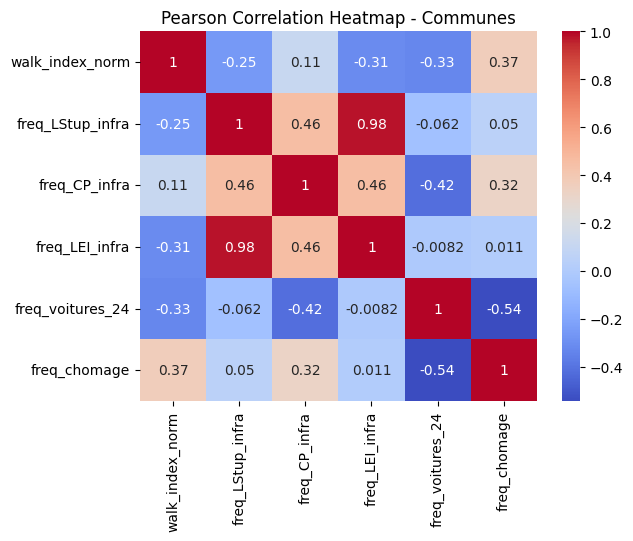

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

colonnes_stat = ['walk_index_norm', 
                 'freq_LStup_infra', 
                 'freq_CP_infra', 
                 'freq_LEI_infra', 
                 #'freq_crim_mean', 
                 'freq_voitures_24',
                 'freq_chomage']

zones_communes_GE_fusionnee_corr = zones_communes_GE_fusionnee[colonnes_stat].corr(method='pearson')
#print(zones_communes_corr)

sns.heatmap(zones_communes_GE_fusionnee_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap - Communes")
plt.show()

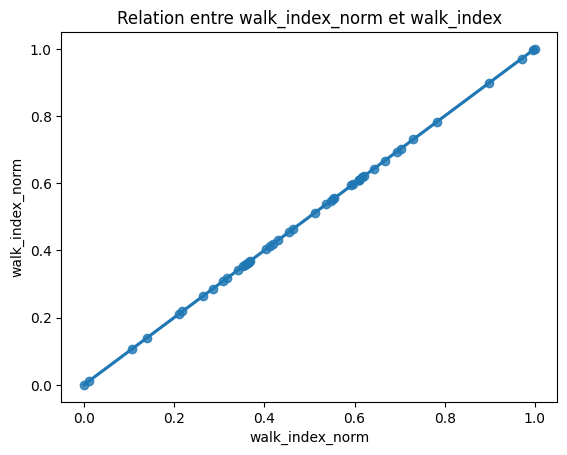

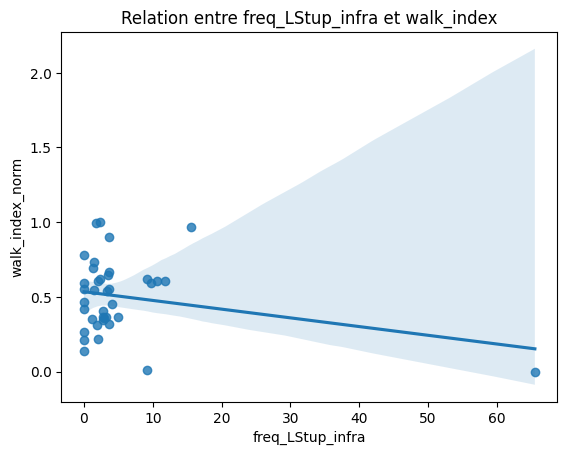

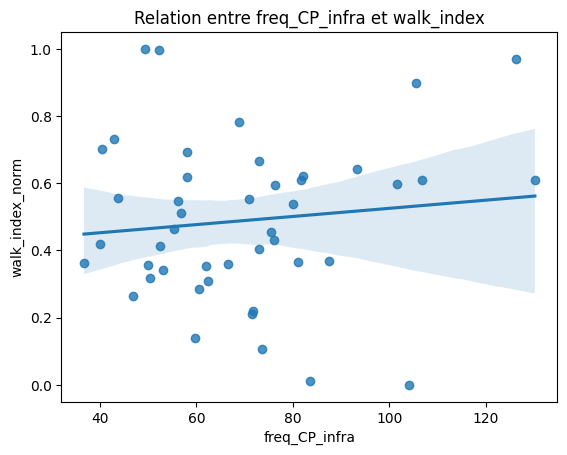

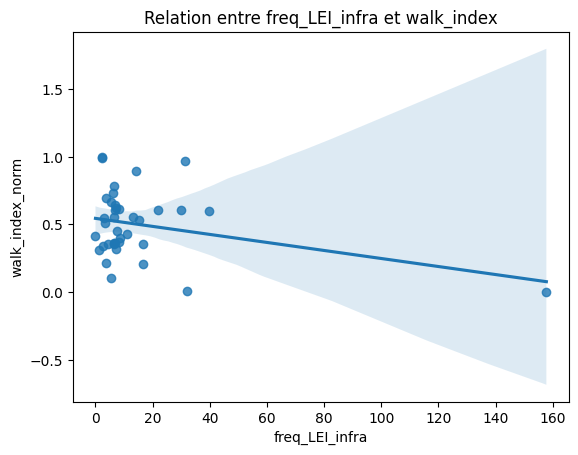

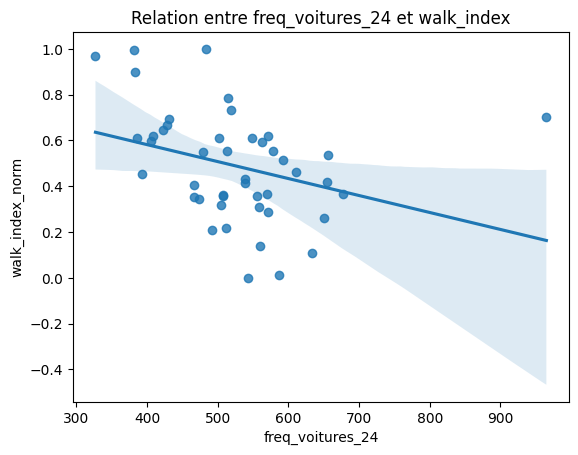

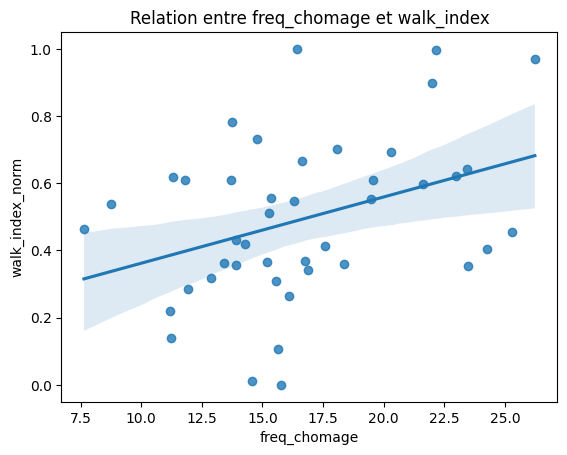

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in colonnes_stat:
    sns.regplot(data=zones_communes_GE_fusionnee, x=var, y='walk_index_norm')
    plt.title(f"Relation entre {var} et walk_index")
    plt.show()

In [79]:
import statsmodels.api as sm

variables = [ 'freq_LStup_infra', 
                 'freq_CP_infra', 
                 'freq_LEI_infra', 
                 #'freq_crim_mean', 
                 'freq_voitures_24',
                 'freq_chomage']

data_reg = zones_communes_GE_fusionnee[variables + ["walk_index_norm"]].dropna()

communes_Nan = zones_communes_GE_fusionnee[['COMMUNE'] + colonnes_stat].loc[zones_communes_GE_fusionnee[colonnes_stat].isna().any(axis=1)]
communes_Nan.head()

,COMMUNE,walk_index_norm,freq_LStup_infra,freq_CP_infra,freq_LEI_infra,freq_voitures_24,freq_chomage
2,Choulex,0.512691,NaN,56.9,3.2,593,15.261044
6,Céligny,0.286164,NaN,60.6,NaN,571,11.918951
7,Cartigny,0.462612,0.0,55.4,NaN,611,7.640879
8,Avusy,0.263227,0.0,46.9,NaN,650,16.106443
9,Avully,0.412629,NaN,52.4,0.0,539,17.563739


In [80]:
X = data_reg[variables]
y = data_reg['walk_index_norm']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        walk_index_norm   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     3.615
Date:                Wed, 22 Apr 2026   Prob (F-statistic):             0.0129
Time:                        10:24:30   Log-Likelihood:                 8.1373
No. Observations:                  32   AIC:                            -4.275
Df Residuals:                      26   BIC:                             4.520
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.6277      0.570  

In [81]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

data_rf = zones_communes_GE_fusionnee[variables + ['walk_index_norm']].dropna()

X = data_rf[variables]
y = data_rf['walk_index_norm']

model = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=variables
).sort_values(ascending=False)

print(importance)

freq_voitures_24    0.406620
freq_LEI_infra      0.276247
freq_LStup_infra    0.127274
freq_CP_infra       0.105599
freq_chomage        0.084261
dtype: float64


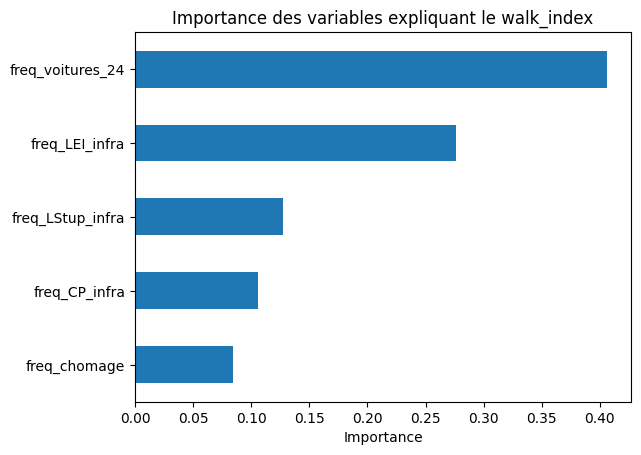

In [82]:
import matplotlib.pyplot as plt

importance.sort_values().plot.barh()

plt.xlabel("Importance")
plt.title("Importance des variables expliquant le walk_index")
plt.show()

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt



data_plot = zones_communes_GE_fusionnee[colonnes_stat].dropna()

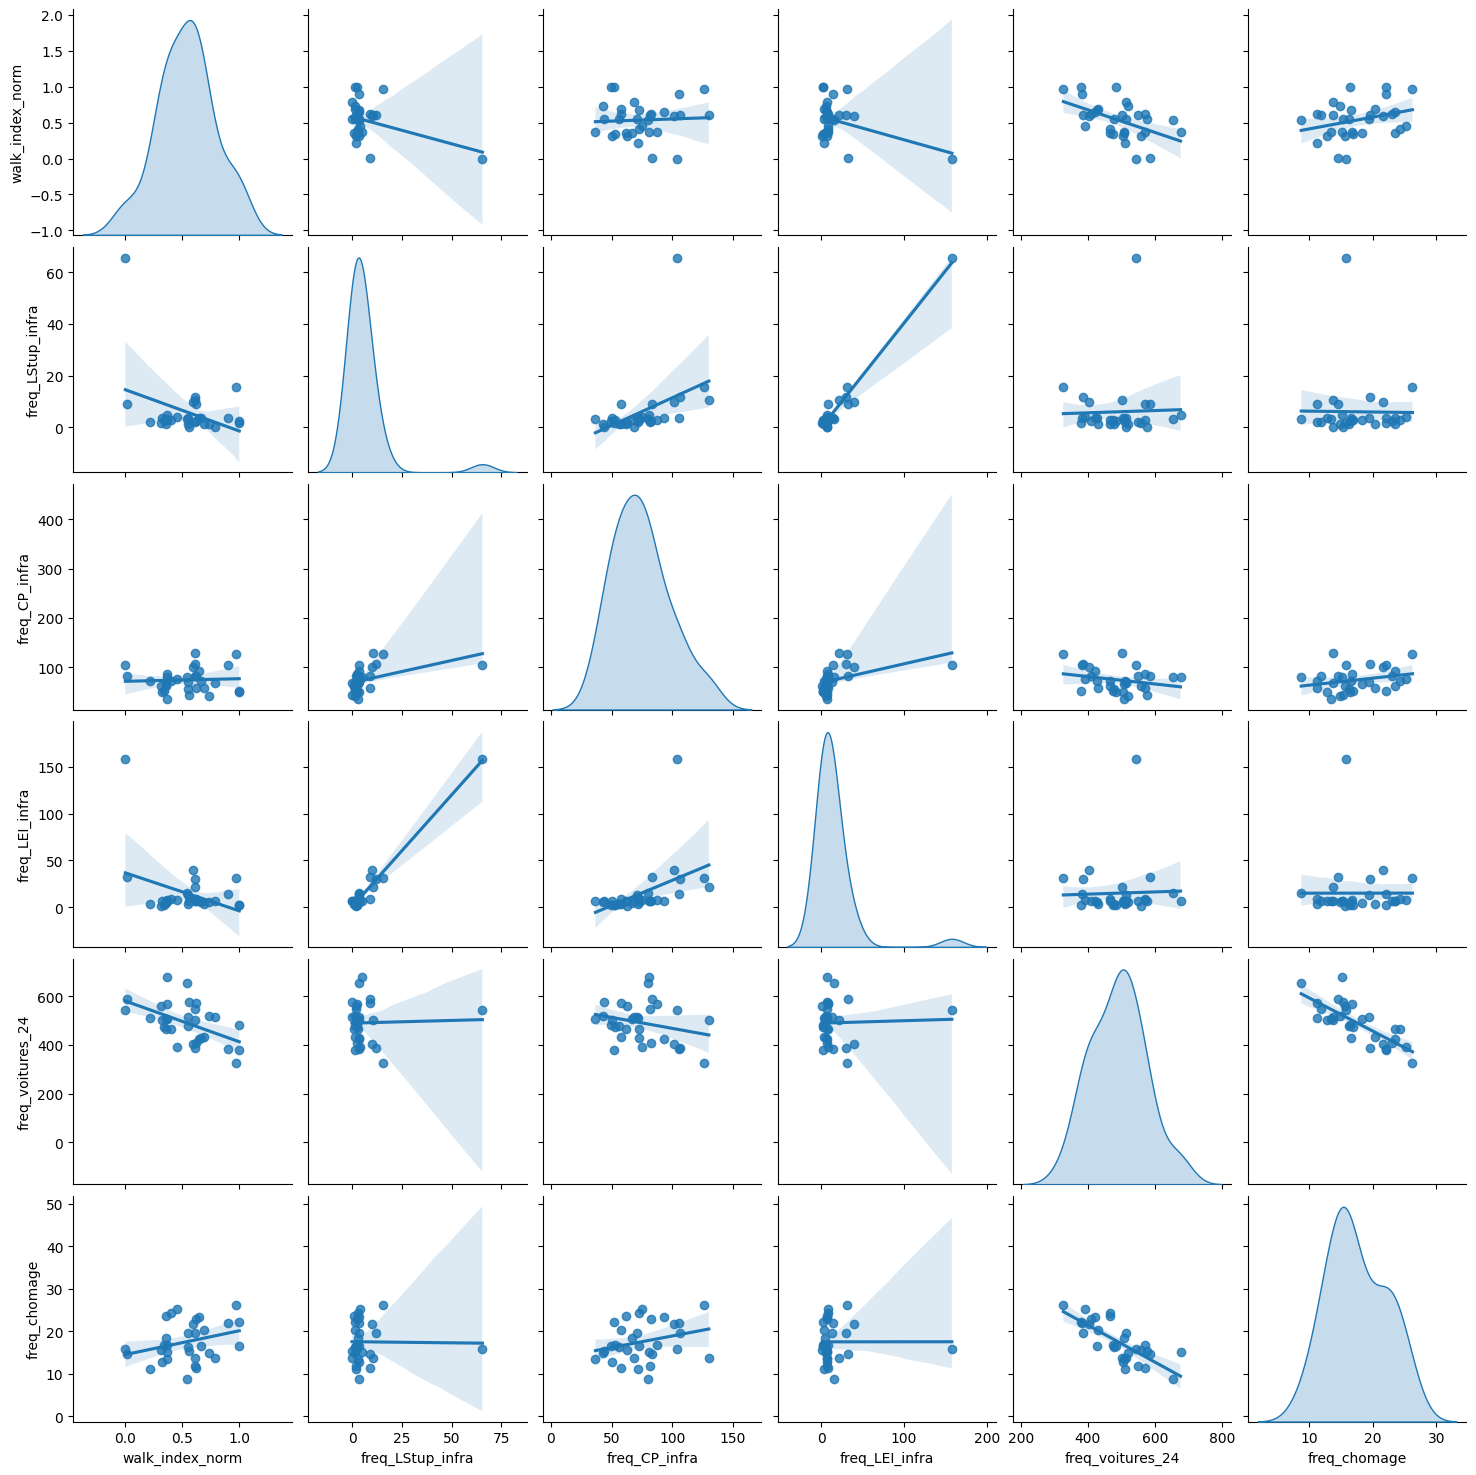

In [84]:
sns.pairplot(
    data_plot,
    kind="reg",
    diag_kind="kde"
)

plt.show()

In [85]:
zones_communes_GE_fusionnee["type_commune"] = "Autres"
zones_communes_GE_fusionnee.loc[
    zones_communes_GE_fusionnee["COMMUNE"] == "Genève",
    "type_commune"
] = "Genève"

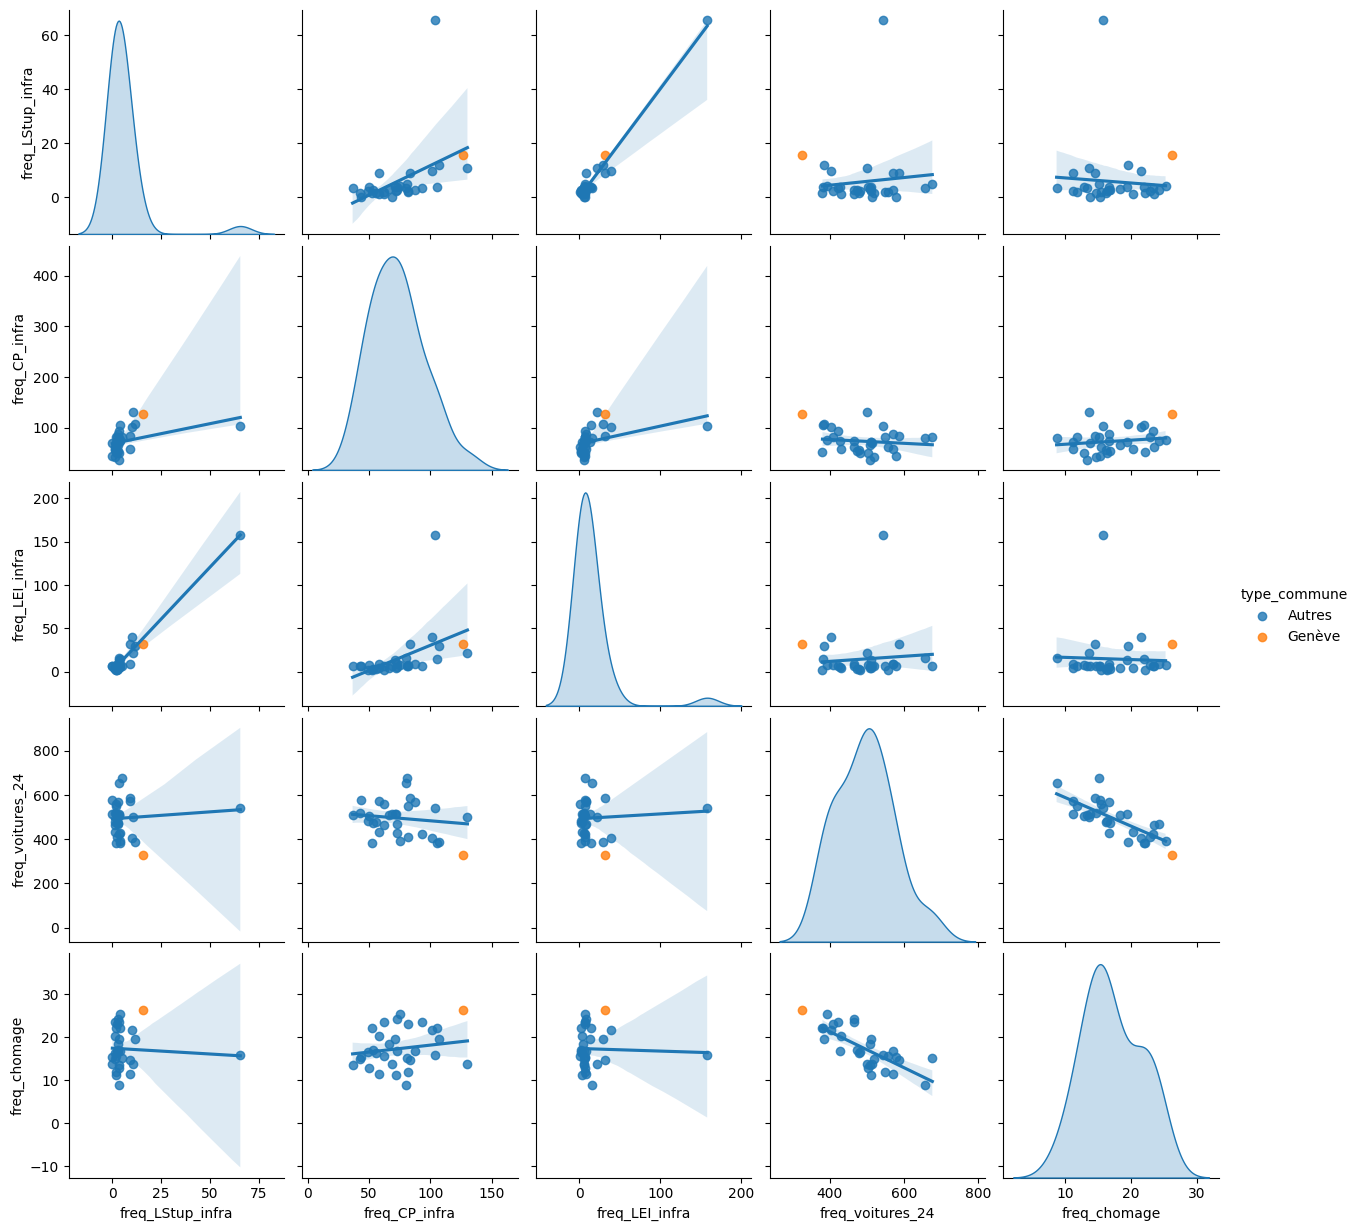

In [86]:
sns.pairplot(
    zones_communes_GE_fusionnee[variables + ["type_commune"]].dropna(),
    hue="type_commune",
    kind="reg",
    diag_kind="kde"
)

plt.show()

## ANALYSES STAT GIREC

### Analyses de corrélation — zones GIREC

Analyse des relations entre `walk_index` et les indicateurs socio-économiques ajoutés.

In [87]:
# Récupère toutes les colonnes à partir de 'precarite_score' (excl. geometry)
cols_all = [c for c in zones_girec.columns if c != 'geometry']
start_col = 'precarite_score_24'
cols_to_exclude = ['freq_chomeurs_inscrits_24', 'freq_eleve_origine_modeste_24', 'part_benef_subs_sociaux_24','part_benef_alloc_logement_24', 'part_bas_revenus_24', 'tot_habitations_25', 'pop_residante_25'] + ib_cols
stat_vars = [d for d in cols_all[cols_all.index(start_col):] if d not in cols_to_exclude]


print(f'{len(stat_vars)} variables sélectionnées :')
print(stat_vars)

data_girec = zones_girec[['walk_index_norm'] + stat_vars].dropna()
print(f'\n{len(data_girec)} sous-secteurs avec données complètes / {len(zones_girec)} total')

19 variables sélectionnées :
['precarite_score_24', 'delta_emploi_24', 'chomeurs_inscrits_24', 'emplois_totaux_24', 'eleve_origine_modeste_24', 'subsides_sociaux_24', 'alloc_logement_24', 'bas_revenus_24', 'revenus_median_24', 'densite_pop_25', '0_19_ans_25', '80_ou_plus_25', '20_64_ans_25', '65_ou_plus_25', 'taux_croissance_pop_24_25', 'hab_20_plus_25', 'hab_20_moins_25', 'maison_indiv_25', 'freq_voitures_24']

218 sous-secteurs avec données complètes / 475 total


### 1. Heatmap de corrélation

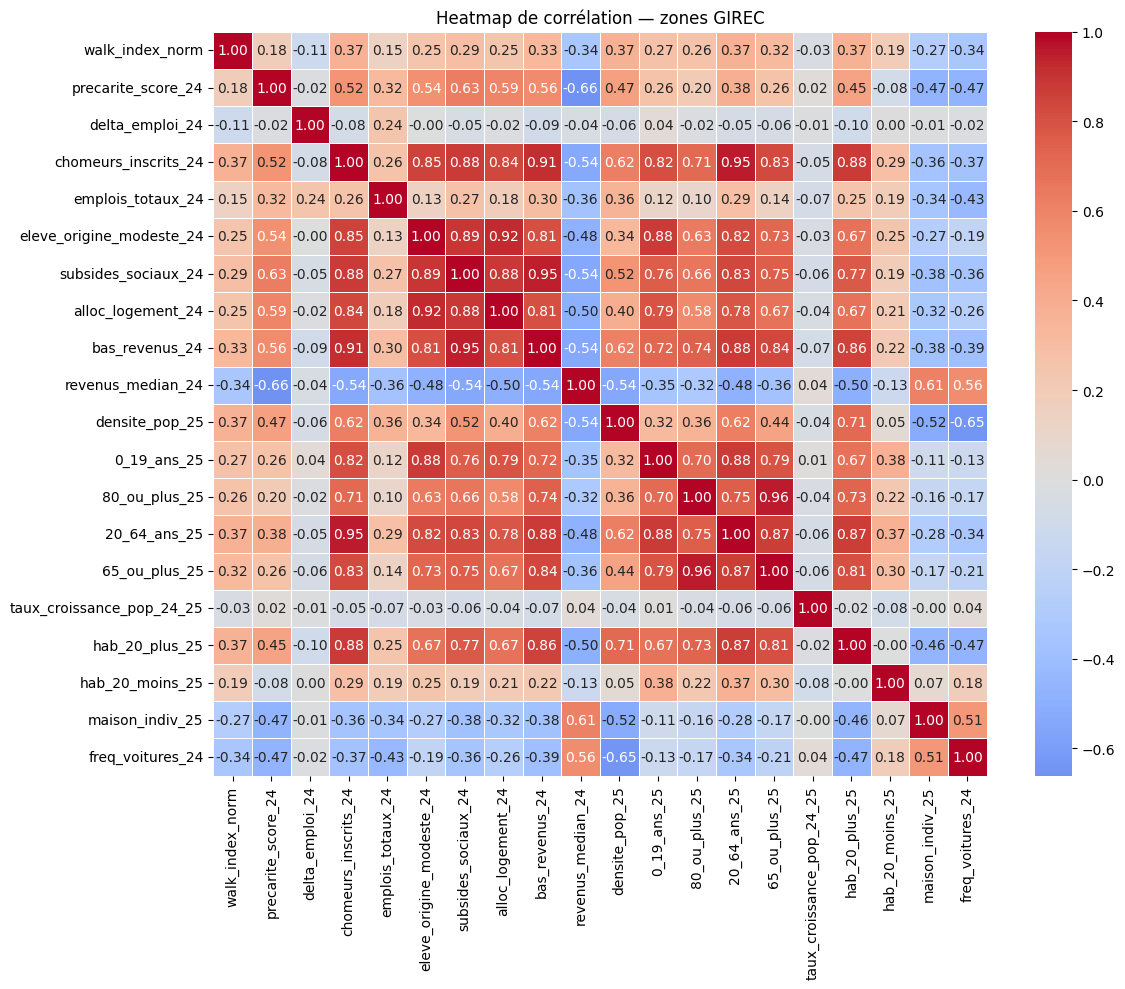

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = data_girec.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Heatmap de corrélation — zones GIREC')
plt.tight_layout()
plt.show()

### 2. VIF — détection de multicolinéarité

Un VIF > 5 signale une colinéarité problématique entre variables.

In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = data_girec[stat_vars].copy()
vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif.to_string(index=False))

                 Variable        VIF
             20_64_ans_25 130.173735
            65_ou_plus_25 127.069219
           bas_revenus_24  73.926938
      subsides_sociaux_24  55.493911
            80_ou_plus_25  49.753862
     chomeurs_inscrits_24  47.829127
              0_19_ans_25  46.026859
 eleve_origine_modeste_24  37.818541
           hab_20_plus_25  33.140986
         freq_voitures_24  25.798909
        revenus_median_24  17.889802
        alloc_logement_24  13.984248
          hab_20_moins_25  11.666674
           densite_pop_25   8.257009
       precarite_score_24   5.895604
          maison_indiv_25   3.932904
        emplois_totaux_24   3.138725
          delta_emploi_24   1.272373
taux_croissance_pop_24_25   1.180580


### 3. OLS — régression linéaire

In [90]:
import statsmodels.api as sm

X_ols = sm.add_constant(data_girec[stat_vars])
y_ols = data_girec['walk_index_norm']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        walk_index_norm   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     3.752
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.11e-06
Time:                        10:24:39   Log-Likelihood:                 153.20
No. Observations:                 218   AIC:                            -266.4
Df Residuals:                     198   BIC:                            -198.7
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### 4. LASSO — sélection automatique de variables

Le LASSO pénalise les coefficients et force les variables non-informatives à 0.

Alpha optimal : 0.0064
hab_20_plus_25               0.024538
freq_voitures_24            -0.024523
hab_20_moins_25              0.023335
revenus_median_24           -0.008984
delta_emploi_24             -0.007294
densite_pop_25               0.005028
maison_indiv_25             -0.001145
alloc_logement_24           -0.000000
bas_revenus_24               0.000000
subsides_sociaux_24         -0.000000
eleve_origine_modeste_24     0.000000
0_19_ans_25                  0.000000
80_ou_plus_25                0.000000
20_64_ans_25                 0.000000
65_ou_plus_25                0.000000
taux_croissance_pop_24_25   -0.000000
emplois_totaux_24           -0.000000
chomeurs_inscrits_24         0.000000
precarite_score_24          -0.000000
dtype: float64


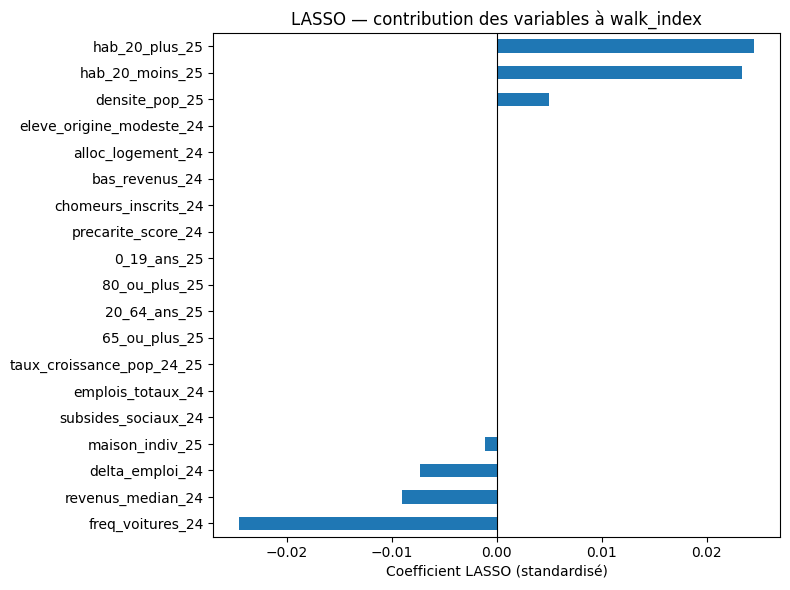

In [91]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_lasso = scaler.fit_transform(data_girec[stat_vars])
y_lasso = data_girec['walk_index_norm'].values

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_lasso, y_lasso)

lasso_coefs = pd.Series(lasso.coef_, index=stat_vars).sort_values(key=abs, ascending=False)
print(f'Alpha optimal : {lasso.alpha_:.4f}')
print(lasso_coefs)

lasso_coefs.sort_values().plot.barh(figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient LASSO (standardisé)')
plt.title('LASSO — contribution des variables à walk_index')
plt.tight_layout()
plt.show()

### 5. Moran's I — autocorrélation spatiale des résidus OLS

Si les résidus sont spatialement autocorrélés, les p-values OLS sont invalides.

In [92]:
import libpysal
from esda.moran import Moran

# Matrice de contiguïté spatiale (Queen)
zones_girec_clean = zones_girec[['geometry'] + ['walk_index_norm'] + stat_vars].dropna()
w = libpysal.weights.Queen.from_dataframe(zones_girec_clean)
w.transform = 'r'

# Résidus OLS sur le sous-ensemble sans NaN
X_m = sm.add_constant(zones_girec_clean[stat_vars])
y_m = zones_girec_clean['walk_index_norm']
residuals = sm.OLS(y_m, X_m).fit().resid

moran = Moran(residuals.values, w)
print(f"Moran's I : {moran.I:.4f}")
print(f'p-value    : {moran.p_sim:.4f}')
print('→ Autocorrélation spatiale significative' if moran.p_sim < 0.05 else '→ Pas d\'autocorrélation spatiale significative')

/var/folders/fm/kg5b8n7n4ns6lqqnwn6zhhkr0000gn/T/ipykernel_40918/1335842468.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(zones_girec_clean)


('WARNING: ', 6, ' is an island (no neighbors)')
('WARNING: ', 11, ' is an island (no neighbors)')
('WARNING: ', 12, ' is an island (no neighbors)')
('WARNING: ', 16, ' is an island (no neighbors)')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 33, ' is an island (no neighbors)')
('WARNING: ', 44, ' is an island (no neighbors)')
('WARNING: ', 51, ' is an island (no neighbors)')
('WARNING: ', 52, ' is an island (no neighbors)')
('WARNING: ', 62, ' is an island (no neighbors)')
('WARNING: ', 63, ' is an island (no neighbors)')
('WARNING: ', 85, ' is an island (no neighbors)')
('WARNING: ', 86, ' is an island (no neighbors)')
('WARNING: ', 92, ' is an island (no neighbors)')
('WARNING: ', 98, ' is an island (no neighbors)')
('WARNING: ', 102, ' is an island (no neighbors)')
('WARNING: ', 159, ' is an island (no neighbors)')
Moran's I : 0.1451
p-value    : 0.0080
→ Autocorrélation spatiale significative


/opt/anaconda3/envs/marchabilite/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 24 disconnected components.
 There are 17 islands with ids: 6, 11, 12, 16, 17, 33, 44, 51, 52, 62, 63, 85, 86, 92, 98, 102, 159.
  W.__init__(self, neighbors, ids=ids, **kw)


### 6. Random Forest — importance des variables

maison_indiv_25              0.093284
emplois_totaux_24            0.083187
subsides_sociaux_24          0.079818
hab_20_moins_25              0.066833
densite_pop_25               0.063618
delta_emploi_24              0.063469
revenus_median_24            0.061949
taux_croissance_pop_24_25    0.060790
eleve_origine_modeste_24     0.056348
hab_20_plus_25               0.055640
20_64_ans_25                 0.054714
0_19_ans_25                  0.052157
chomeurs_inscrits_24         0.042293
alloc_logement_24            0.032776
65_ou_plus_25                0.031583
bas_revenus_24               0.029407
80_ou_plus_25                0.027559
freq_voitures_24             0.025749
precarite_score_24           0.018825
dtype: float64


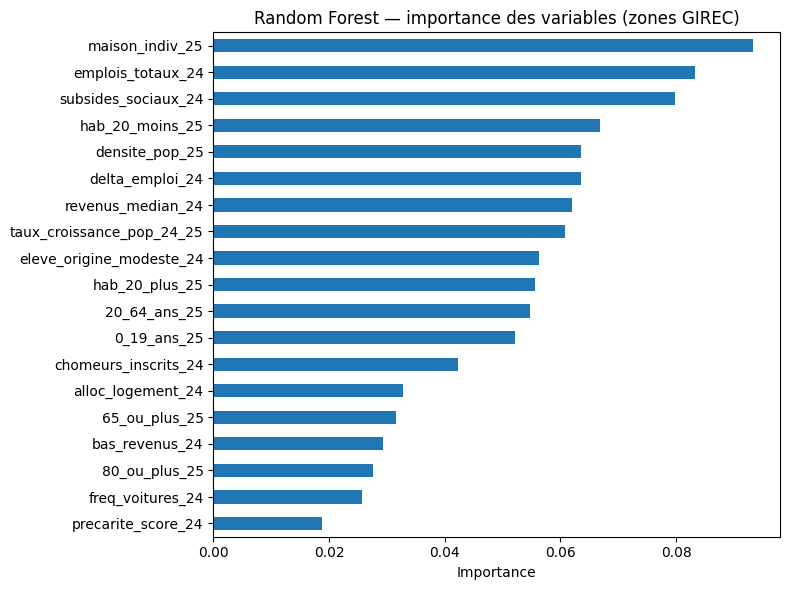

In [93]:
from sklearn.ensemble import RandomForestRegressor

X_rf = data_girec[stat_vars]
y_rf = data_girec['walk_index_norm']

rf = RandomForestRegressor(n_estimators=1000, random_state=42)
rf.fit(X_rf, y_rf)

importance_girec = pd.Series(rf.feature_importances_, index=stat_vars).sort_values(ascending=False)
print(importance_girec)

importance_girec.sort_values().plot.barh(figsize=(8, 6))
plt.xlabel('Importance')
plt.title('Random Forest — importance des variables (zones GIREC)')
plt.tight_layout()
plt.show()

### 7. Pairplot — top 6 variables corrélées à walk_index

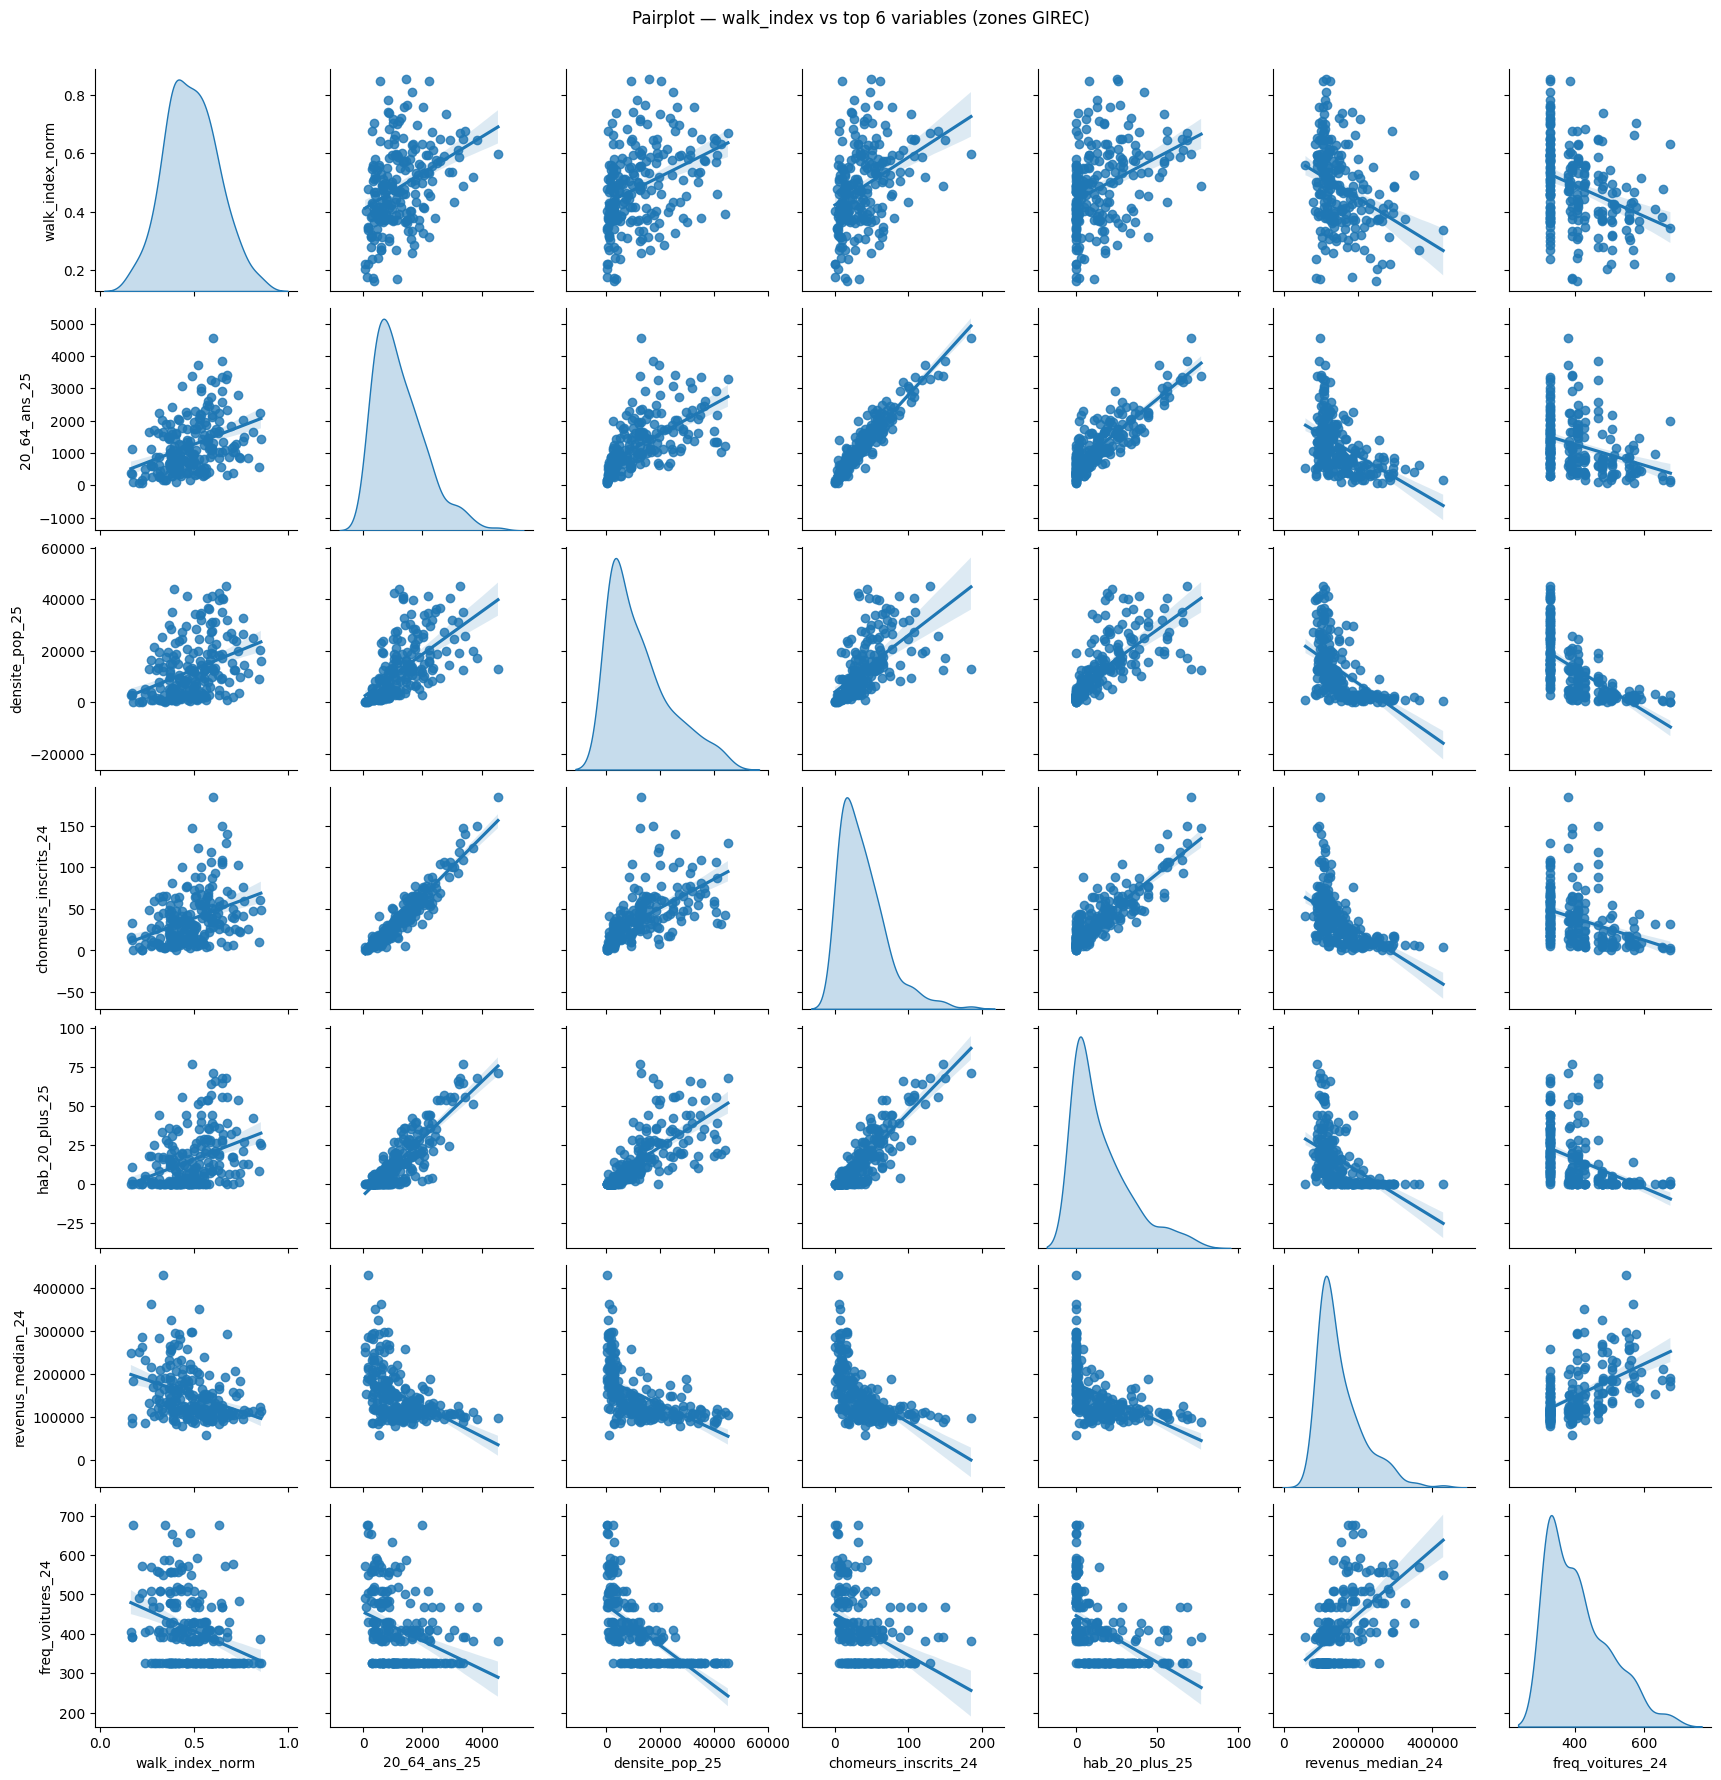

In [94]:
# Sélection des 6 variables les plus corrélées à walk_index
top_vars = corr['walk_index_norm'].drop('walk_index_norm').abs().sort_values(ascending=False).head(6).index.tolist()

sns.pairplot(
    data_girec[['walk_index_norm'] + top_vars],
    kind='reg',
    diag_kind='kde'
)
plt.suptitle('Pairplot — walk_index vs top 6 variables (zones GIREC)', y=1.02)
plt.show()

## Zones d'action prioritaires

 Croisement marchabilité × besoin social pour identifier les sous-secteurs prioritaires.

### 1. Scatter walk_index × score précarité 

In [95]:
import plotly.express as px

df_plot = zones_girec[['walk_index_norm', 'precarite_score_24', 'revenus_median_24', 'chomeurs_inscrits_24', 'NOM', 'COMMUNE', 'CODE']].dropna()
#df_plot['NO_COM_FED'] = df_plot['NO_COM_FED'].astype(str)

fig = px.scatter(
    df_plot,
    x='walk_index_norm',
    y='precarite_score_24',
    color='COMMUNE',
    hover_data={
        'NOM': True,
        'CODE': True,
        'COMMUNE': True,
        'walk_index_norm': ':.3f',
        'precarite_score_24': True,
        'chomeurs_inscrits_24': True
    },
    labels={
        'walk_index_norm': 'Walk Index',
        'precarite_score_24': 'Score de precarité',
        'COMMUNE': 'Commune'
    },
    title='Marchabilité vs Precarité par sous-secteur GIREC',
    opacity=0.8,
    width=950,
    height=650
)

# Lignes médianes
fig.add_hline(y=df_plot['precarite_score_24'].median(), line_dash='dash', line_color='gray', line_width=1)
fig.add_vline(x=df_plot['walk_index_norm'].median(), line_dash='dash', line_color='gray', line_width=1)

# Annotations quadrants
med_w = df_plot['walk_index_norm'].median()
med_r = df_plot['precarite_score_24'].median()
fig.add_annotation(x=df_plot['walk_index_norm'].min(), y=df_plot['precarite_score_24'].max(),
    text="Faible marcha. · Precarité élevée", showarrow=False, font=dict(color='steelblue', size=10), xanchor='left')
fig.add_annotation(x=med_w * 1.01, y=df_plot['precarite_score_24'].max(),
    text="Bonne marcha. · Precarité élevée", showarrow=False, font=dict(color='green', size=10), xanchor='left')
fig.add_annotation(x=df_plot['walk_index_norm'].min(), y=df_plot['precarite_score_24'].min(),
    text="⚑ Faible marcha. · Precarité faible", showarrow=False, font=dict(color='red', size=10), xanchor='left')
fig.add_annotation(x=med_w * 1.01, y=df_plot['precarite_score_24'].min(),
    text="Bonne marcha. · Precarité faible", showarrow=False, font=dict(color='orange', size=10), xanchor='left')

fig.show()

/var/folders/fm/kg5b8n7n4ns6lqqnwn6zhhkr0000gn/T/ipykernel_40918/744352555.py:9: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



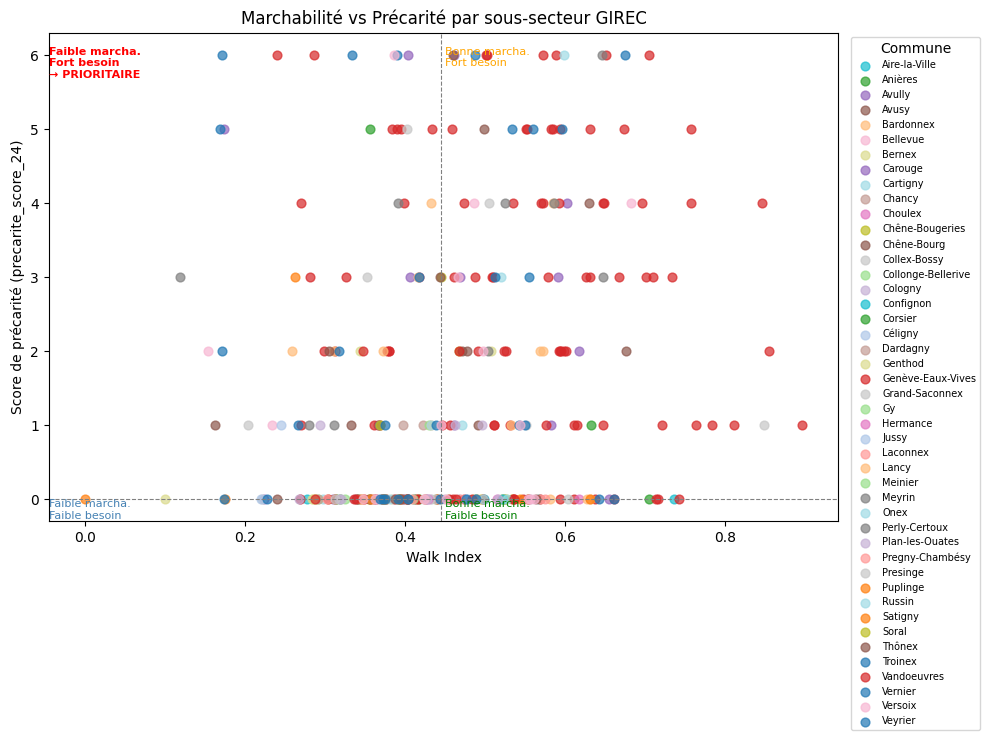

In [96]:
import matplotlib.pyplot as plt

df_plot = zones_girec[['walk_index_norm', 'precarite_score_24', 'NOM', 'COMMUNE']].dropna()

fig, ax = plt.subplots(figsize=(10, 7))

# Points colorés par commune
communes = df_plot['COMMUNE'].unique()
cmap = plt.cm.get_cmap('tab20', len(communes))
color_map = {c: cmap(i) for i, c in enumerate(communes)}

for commune, grp in df_plot.groupby('COMMUNE'):
    ax.scatter(grp['walk_index_norm'], grp['precarite_score_24'],
               color=color_map[commune], label=commune, alpha=0.7, s=40)

# Lignes médianes
ax.axvline(df_plot['walk_index_norm'].median(), color='gray', linestyle='--', linewidth=0.8)
ax.axhline(df_plot['precarite_score_24'].median(), color='gray', linestyle='--', linewidth=0.8)

# Annotations quadrants
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
mx = df_plot['walk_index_norm'].median()
my = df_plot['precarite_score_24'].median()
ax.text(xmin, ymax * 0.97, 'Faible marcha.\nFort besoin\n→ PRIORITAIRE',
        fontsize=8, color='red', fontweight='bold', va='top')
ax.text(mx * 1.01, ymax * 0.97, 'Bonne marcha.\nFort besoin',
        fontsize=8, color='orange', va='top')
ax.text(xmin, my * 0.5, 'Faible marcha.\nFaible besoin',
        fontsize=8, color='steelblue', va='top')
ax.text(mx * 1.01, my * 0.5, 'Bonne marcha.\nFaible besoin',
        fontsize=8, color='green', va='top')

ax.set_xlabel('Walk Index')
ax.set_ylabel('Score de précarité (precarite_score_24)')
ax.set_title('Marchabilité vs Précarité par sous-secteur GIREC')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', title='Commune')
plt.tight_layout()
plt.show()

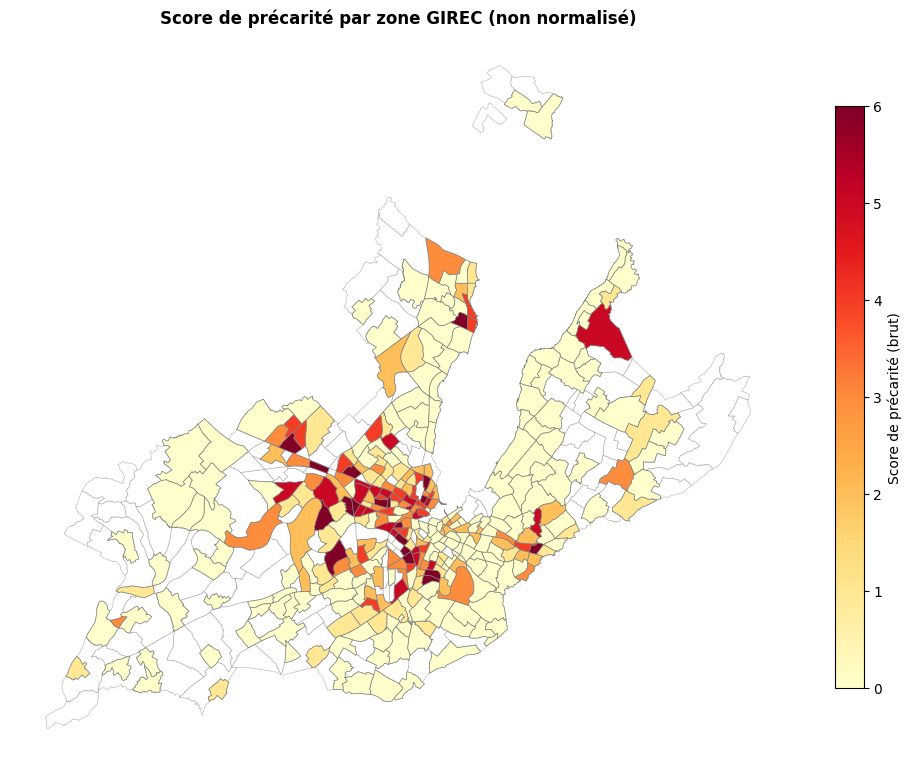

In [97]:
fig, ax = plt.subplots(figsize=(10, 10))

# ← background zones_girec en gris clair
zones_girec.plot(ax=ax, color="white", edgecolor=(0.5, 0.5, 0.5, 0.5), linewidth=0.5)

# ← plot principal par dessus
zones_girec.dropna(subset=["precarite_score_24"]).plot(
    column="precarite_score_24",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Score de précarité (brut)", "shrink": 0.6}
)

#canton_GE.boundary.plot(ax=ax, color="black", linewidth=1.5)
ax.set_title("Score de précarité par zone GIREC (non normalisé)", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 2. Score de priorité — faible marchabilité × fort besoin social

In [98]:
scaler = MinMaxScaler()
df_prio = zones_girec[['walk_index', 'walk_index_norm',  'precarite_score_24', 'NOM', 'NO_COM_FED', 'COMMUNE', 'geometry']].dropna().copy()

# precarite_score_24 normalisé 0-1 (plus c'est élevé = plus précaire = plus besoin d'action)
df_prio['precarity_norm'] = scaler.fit_transform(df_prio[['precarite_score_24']])

# Priority score : fort quand marchabilité FAIBLE et précarité ÉLEVÉE
df_prio['priority_score'] = (1 - df_prio['walk_index_norm']) * df_prio['precarity_norm']

# Top 20 zones prioritaires
top20 = df_prio.nlargest(20, 'priority_score')[['NOM', 'COMMUNE', 'walk_index', 'walk_index_norm', 'precarite_score_24', 'precarity_norm', 'priority_score']]
print(f'{len(df_prio)} sous-secteurs avec données complètes / {len(zones_girec)} total')
print()
print('Top 20 zones prioritaires :')
print(top20.to_string(index=False))

351 sous-secteurs avec données complètes / 475 total

Top 20 zones prioritaires :
                           NOM           COMMUNE  walk_index  walk_index_norm  precarite_score_24  precarity_norm  priority_score
                Champs-Prévost           Vernier    0.274012         0.171579                 6.0        1.000000        0.828421
                   Les Vernets Genève-Eaux-Vives    0.307907         0.239879                 6.0        1.000000        0.760121
                        Valais Genève-Eaux-Vives    0.330975         0.286361                 6.0        1.000000        0.713639
 Rte de Peney - Crotte-au-Loup           Vernier    0.272687         0.168909                 5.0        0.833333        0.692576
           La Praille - BAYLON           Carouge    0.275059         0.173689                 5.0        0.833333        0.688592
                    Libellules           Vernier    0.354402         0.333569                 6.0        1.000000        0.666431
        

In [99]:
df_prio.isna().sum()

walk_index            0
walk_index_norm       0
precarite_score_24    0
NOM                   0
NO_COM_FED            0
COMMUNE               0
geometry              0
precarity_norm        0
priority_score        0
dtype: int64

### 3. Carte — score de priorité

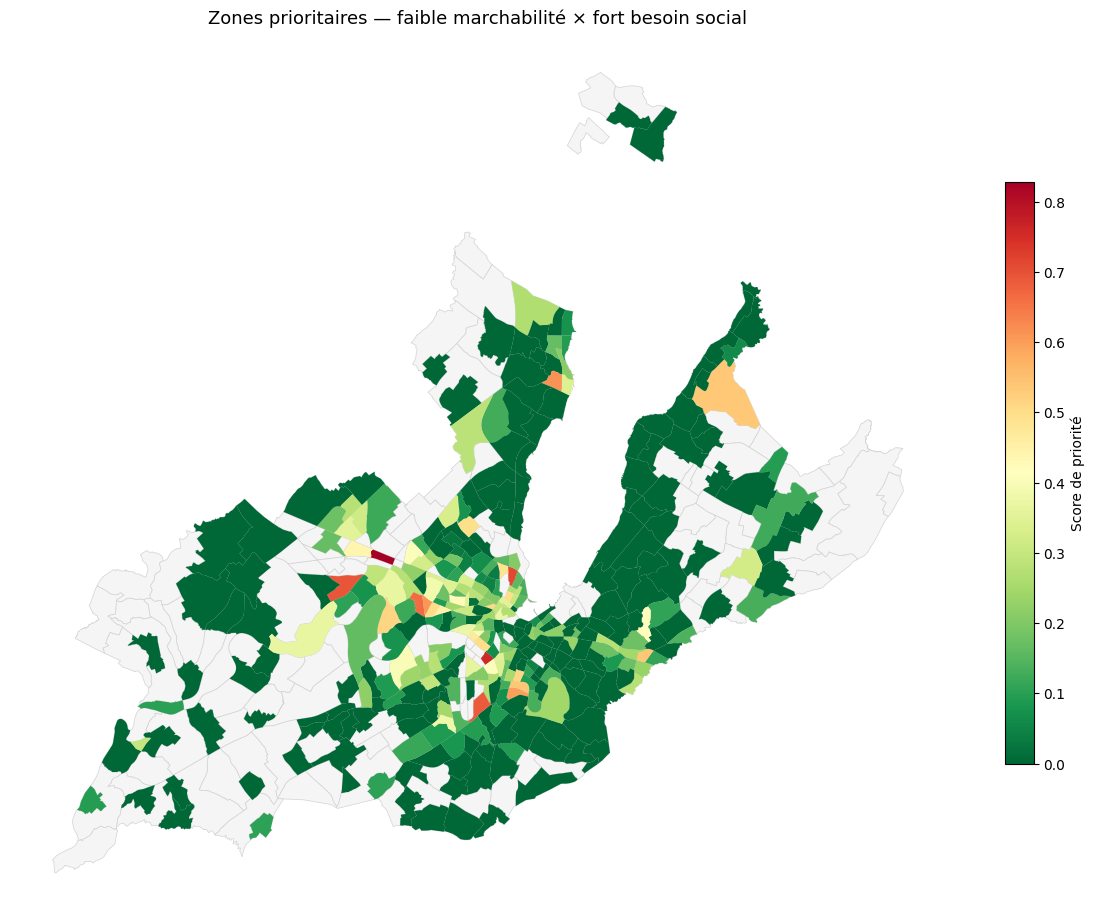

In [100]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf_prio = gpd.GeoDataFrame(df_prio, geometry='geometry', crs=zones_girec.crs)

fig, ax = plt.subplots(figsize=(12, 10))

# Fond : délimitation de tous les sous-secteurs (y compris sans données)
zones_girec.to_crs(gdf_prio.crs).plot(
    ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5
)

# Dessus : score de priorité
gdf_prio.plot(
    column='priority_score',
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Score de priorité', 'shrink': 0.6},
    ax=ax
)

ax.set_title('Zones prioritaires — faible marchabilité × fort besoin social', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [101]:
#replace les colonnes créées au bon endroit dans zones_girec

# walk_index_norm n'est PAS modifié dans df_prio — ne pas le réassigner
# (df_prio a été créé avec dropna, ce qui introduirait 124 NaN par alignement d'index)
zones_girec['precarity_norm'] = df_prio['precarity_norm']
zones_girec['priority_score'] = df_prio['priority_score']

cols = zones_girec.columns.tolist()
for col, after in [
    ('walk_index_norm',      'walk_index'),
    ('precarity_norm', 'precarite_score_24'),
    ('priority_score', 'precarity_norm')
]:
    cols.insert(cols.index(after) + 1, cols.pop(cols.index(col)))
zones_girec = zones_girec[cols]

In [102]:
zones_girec.columns

Index(['OBJECTID', 'NOM', 'COMMUNE', 'NO_COM_FED', 'NO_COMM', 'CODE_SECT',
       'SECT_VILLE', 'NUMERO', 'CD_SS_SECT', 'SHAPE_AREA', 'SHAPE_LEN',
       'geometry', 'lac_cours_deau', 'fontaine', 'espaces_ouverts',
       'rez_actif', 'tp', 'amenite', 'bruit', 'temperature', 'conflit_md',
       'canopee', 'banc', 'toilette', 'air', 'connectivite', 'chemin',
       'stationnement_genant', 'accident', 'zone_apaisee', 'vitesse',
       'eclairage', 'walk_index', 'walk_index_norm', 'walk_index_unweighted',
       'Classe_Attractivité', 'Classe_Commodité', 'Classe_Infrastructure',
       'Classe_Sécurité', 'CODE', 'precarite_score_24', 'precarity_norm',
       'priority_score', 'IB1_quartiles_24', 'IB2_quartiles_24',
       'IB3_quartiles_24', 'IB4_quartiles_24', 'IB5_quartiles_24',
       'IB6_quartiles_24', 'delta_emploi_24', 'freq_chomeurs_inscrits_24',
       'chomeurs_inscrits_24', 'emplois_totaux_24', 'eleve_origine_modeste_24',
       'freq_eleve_origine_modeste_24', 'subsides_socia

### 4. Clustering K-Means — profils de sous-secteurs

4 clusters : bonne marcha./aisé · bonne marcha./précaire · mauvaise marcha./aisé · mauvaise marcha./précaire

In [103]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

cluster_vars = ['walk_index_norm', 'precarite_score_24']
df_clust = zones_girec[['NOM', 'NO_COM_FED', 'geometry'] + cluster_vars].dropna().copy()

scaler_k = StandardScaler()
X_clust = scaler_k.fit_transform(df_clust[cluster_vars])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clust['cluster'] = kmeans.fit_predict(X_clust)

# Profil moyen de chaque cluster
profile = df_clust.groupby('cluster')[cluster_vars].mean().round(3)
print("Profil moyen par cluster :")
print(profile)
print()
print("Nombre de sous-secteurs par cluster :")
print(df_clust['cluster'].value_counts().sort_index())

Profil moyen par cluster :
         walk_index_norm  precarite_score_24
cluster                                     
0                  0.567               0.604
1                  0.384               4.442
2                  0.620               4.184
3                  0.350               0.340

Nombre de sous-secteurs par cluster :
cluster
0    106
1     43
2     49
3    153
Name: count, dtype: int64


In [104]:
# Nommer les clusters selon leur profil
centers = df_clust.groupby('cluster')[['walk_index_norm', 'precarite_score_24']].mean()
labels = {}
for i, row in centers.iterrows():
    walk_high = row['walk_index_norm'] > centers['walk_index_norm'].median()
    prec_high = row['precarite_score_24'] > centers['precarite_score_24'].median()
    if walk_high and prec_high:
        labels[i] = 'Bonne marcha. · Précaire'
    elif walk_high and not prec_high:
        labels[i] = 'Bonne marcha. · Aisé'
    elif not walk_high and prec_high:
        labels[i] = 'Faible marcha. · Précaire ⚠︎'
    else:
        labels[i] = 'Faible marcha. · Aisé'

df_clust['cluster_label'] = df_clust['cluster'].map(labels)

# ─── Afficher labels + valeurs moyennes des clusters ──────────────────────────
print("── Clusters avec valeurs moyennes ───────────────────")
for i, label in labels.items():
    row = centers.loc[i]
    print(f"  {label:<35} walk_index_norm={row['walk_index_norm']:.3f}  precarite={row['precarite_score_24']:.3f}")

print()
print("── Nombre de zones par cluster ──────────────────────")
print(df_clust['cluster_label'].value_counts())

── Clusters avec valeurs moyennes ───────────────────
  Bonne marcha. · Aisé                walk_index_norm=0.567  precarite=0.604
  Faible marcha. · Précaire ⚠︎        walk_index_norm=0.384  precarite=4.442
  Bonne marcha. · Précaire            walk_index_norm=0.620  precarite=4.184
  Faible marcha. · Aisé               walk_index_norm=0.350  precarite=0.340

── Nombre de zones par cluster ──────────────────────
cluster_label
Faible marcha. · Aisé           153
Bonne marcha. · Aisé            106
Bonne marcha. · Précaire         49
Faible marcha. · Précaire ⚠︎     43
Name: count, dtype: int64


In [105]:
df_clust

,NOM,NO_COM_FED,geometry,walk_index_norm,precarite_score_24,cluster,cluster_label
5,Grand-Donzel,6645,"POLYGON ((2502328.619 1113837.827, 2502276.69 ...",0.489265,0.0,0,Bonne marcha. · Aisé
6,Bois-de-Veyrier,6645,"POLYGON ((2501575.401 1113832.583, 2501634.134...",0.368949,0.0,3,Faible marcha. · Aisé
7,Tournettes,6645,"POLYGON ((2503082.334 1113230.511, 2503070.815...",0.642637,0.0,0,Bonne marcha. · Aisé
8,Rasses,6645,"POLYGON ((2502618.366 1113627.023, 2502608.84 ...",0.372391,0.0,3,Faible marcha. · Aisé
9,Troinex - Marais,6641,"POLYGON ((2501393.638 1112923.836, 2501503.254...",0.228248,0.0,3,Faible marcha. · Aisé
...,...,...,...,...,...,...,...
467,Sézenove,6607,"POLYGON ((2493611.593 1112951.287, 2493604.179...",0.445591,0.0,3,Faible marcha. · Aisé
469,Cressy - Molliers,6607,"POLYGON ((2495761.138 1115018.541, 2495756.981...",0.343529,2.0,3,Faible marcha. · Aisé
470,Saint-Paul,6617,"POLYGON ((2502534.207 1117935.101, 2502537.887...",0.449850,0.0,3,Faible marcha. · Aisé
473,Les Délices,6621,"POLYGON ((2499204.951 1117986.706, 2499180.133...",0.611741,0.0,0,Bonne marcha. · Aisé


In [106]:
df_clust.isna().sum()

NOM                   0
NO_COM_FED            0
geometry              0
walk_index_norm       0
precarite_score_24    0
cluster               0
cluster_label         0
dtype: int64

In [107]:
# ─── Liste des zones "Faible marcha. · Précaire" avec stats du cluster ────────
mask = df_clust["cluster_label"] == "Faible marcha. · Précaire ⚠︎"
subset = df_clust[mask]

# Stats du cluster
print(f"── Cluster : Faible marcha. · Précaire ⚠︎ ({mask.sum()} zones) ────────")
print(f"   walk_index moyen      : {subset['walk_index_norm'].mean():.3f}")
print(f"   precarite_score moyen : {subset['precarite_score_24'].mean():.3f}")
print(f"   walk_index médian     : {subset['walk_index_norm'].median():.3f}")
print(f"   precarite_score médian: {subset['precarite_score_24'].median():.3f}")
print()

# Liste des zones
print(f"── Liste des zones ───────────────────────────────────────────────────")
print(subset[["NOM", "walk_index_norm", "precarite_score_24"]]
      .sort_values("precarite_score_24", ascending=False)
      .to_string(index=False))

── Cluster : Faible marcha. · Précaire ⚠︎ (43 zones) ────────
   walk_index moyen      : 0.384
   precarite_score moyen : 4.442
   walk_index médian     : 0.404
   precarite_score médian: 5.000

── Liste des zones ───────────────────────────────────────────────────
                               NOM  walk_index_norm  precarite_score_24
              Châtelaine - SIMONET         0.389683                 6.0
                          ANSERMET         0.501152                 6.0
                        Crève-Cœur         0.386758                 6.0
                         Le Lignon         0.487245                 6.0
                Fontenette - stade         0.460993                 6.0
               Fontenette - GEVRIL         0.404081                 6.0
                       Les Vernets         0.239879                 6.0
                   Pâquis - temple         0.503049                 6.0
                            Valais         0.286361                 6.0
              

### 5. Carte des clusters

/var/folders/fm/kg5b8n7n4ns6lqqnwn6zhhkr0000gn/T/ipykernel_40918/3585770210.py:25: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.



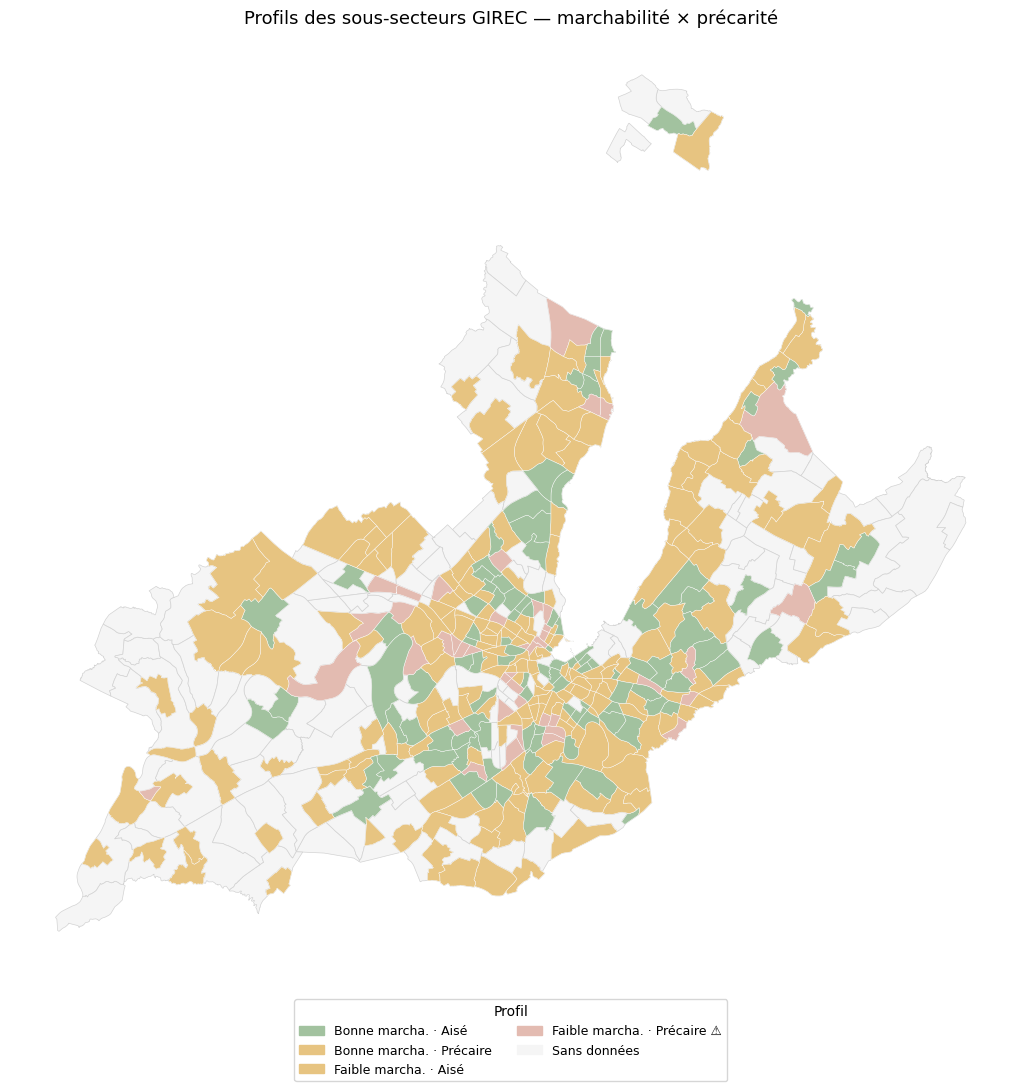

In [108]:
import matplotlib.patches as mpatches

gdf_clust = gpd.GeoDataFrame(df_clust, geometry='geometry', crs=zones_girec.crs)

cluster_colors = {
    'Bonne marcha. · Aisé':        '#a2c29fff',
    'Bonne marcha. · Précaire':    '#e7c481ff',
    'Faible marcha. · Aisé':       '#e7c481ff',
    'Faible marcha. · Précaire ⚠︎': '#e3bbb1ff'
}

gdf_clust['color'] = gdf_clust['cluster_label'].map(cluster_colors).fillna('lightgrey')

fig, ax = plt.subplots(figsize=(13, 11))

# Fond : tous les sous-secteurs (zones sans données = whitesmoke)
zones_girec.to_crs(gdf_clust.crs).plot(
    ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5
)

# Dessus : clusters colorés
gdf_clust.plot(color=gdf_clust['color'], ax=ax, edgecolor='white', linewidth=0.3)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in cluster_colors.items()]
legend_patches.append(mpatches.Patch(color='whitesmoke', edgecolor='lightgrey', label='Sans données'))
ax.set_title('Profils des sous-secteurs GIREC — marchabilité × précarité', fontsize=13)
ax.set_axis_off()

ax.legend(
    handles=legend_patches,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),  # ← en dessous du plot
    ncol=2,
    fontsize=9,
    title="Profil",
    frameon=True
)

plt.tight_layout()
plt.show()

In [109]:
zones_girec['cluster'] = df_clust['cluster']
zones_girec['cluster_label'] = df_clust['cluster_label']

cols = zones_girec.columns.tolist()
for col, after in [
    ('cluster',      'priority_score'),
    ('cluster_label', 'cluster')
]:
    cols.insert(cols.index(after) + 1, cols.pop(cols.index(col)))
zones_girec = zones_girec[cols]


In [110]:
zones_girec.columns

Index(['OBJECTID', 'NOM', 'COMMUNE', 'NO_COM_FED', 'NO_COMM', 'CODE_SECT',
       'SECT_VILLE', 'NUMERO', 'CD_SS_SECT', 'SHAPE_AREA', 'SHAPE_LEN',
       'geometry', 'lac_cours_deau', 'fontaine', 'espaces_ouverts',
       'rez_actif', 'tp', 'amenite', 'bruit', 'temperature', 'conflit_md',
       'canopee', 'banc', 'toilette', 'air', 'connectivite', 'chemin',
       'stationnement_genant', 'accident', 'zone_apaisee', 'vitesse',
       'eclairage', 'walk_index', 'walk_index_norm', 'walk_index_unweighted',
       'Classe_Attractivité', 'Classe_Commodité', 'Classe_Infrastructure',
       'Classe_Sécurité', 'CODE', 'precarite_score_24', 'precarity_norm',
       'priority_score', 'cluster', 'cluster_label', 'IB1_quartiles_24',
       'IB2_quartiles_24', 'IB3_quartiles_24', 'IB4_quartiles_24',
       'IB5_quartiles_24', 'IB6_quartiles_24', 'delta_emploi_24',
       'freq_chomeurs_inscrits_24', 'chomeurs_inscrits_24',
       'emplois_totaux_24', 'eleve_origine_modeste_24',
       'freq_eleve_o

### 6. Scatter walk_index × revenus médian coloré par cluster

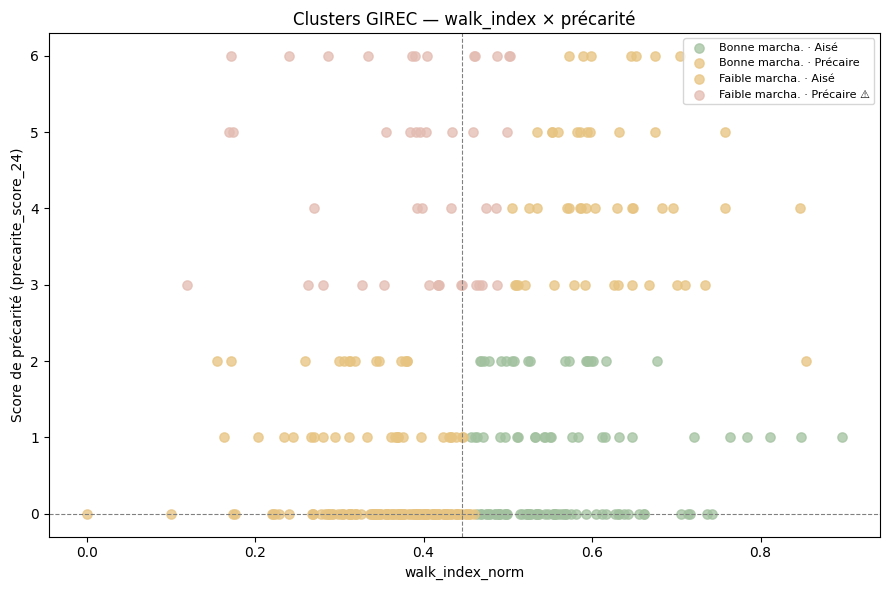

In [111]:
fig, ax = plt.subplots(figsize=(9, 6))
for label, grp in gdf_clust.groupby('cluster_label'):
    ax.scatter(grp['walk_index_norm'], grp['precarite_score_24'],
               color=cluster_colors[label], label=label, alpha=0.75, s=45)

ax.axvline(gdf_clust['walk_index_norm'].median(), color='gray', linestyle='--', linewidth=0.8)
ax.axhline(gdf_clust['precarite_score_24'].median(), color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('walk_index_norm')
ax.set_ylabel('Score de précarité (precarite_score_24)')
ax.set_title('Clusters GIREC — walk_index × précarité')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [112]:
# ─── Centres des clusters dans l'espace original (non standardisé) ────────────
centers_original = df_clust.groupby('cluster_label')[cluster_vars].mean().round(3)
print("── Centres des clusters (valeurs originales) ────────")
print(centers_original)
print()

# ─── Valeurs min/max de chaque cluster ────────────────────────────────────────
print("── Plages de valeurs par cluster ────────────────────")
for label in df_clust['cluster_label'].unique():
    subset = df_clust[df_clust['cluster_label'] == label]
    print(f"\n{label} ({len(subset)} zones) :")
    print(f"  walk_index       : {subset['walk_index_norm'].min():.3f} → {subset['walk_index_norm'].max():.3f}  (mean: {subset['walk_index_norm'].mean():.3f})")
    print(f"  precarite_score  : {subset['precarite_score_24'].min():.3f} → {subset['precarite_score_24'].max():.3f}  (mean: {subset['precarite_score_24'].mean():.3f})")

── Centres des clusters (valeurs originales) ────────
                              walk_index_norm  precarite_score_24
cluster_label                                                    
Bonne marcha. · Aisé                    0.567               0.604
Bonne marcha. · Précaire                0.620               4.184
Faible marcha. · Aisé                   0.350               0.340
Faible marcha. · Précaire ⚠︎            0.384               4.442

── Plages de valeurs par cluster ────────────────────

Bonne marcha. · Aisé (106 zones) :
  walk_index       : 0.456 → 0.897  (mean: 0.567)
  precarite_score  : 0.000 → 2.000  (mean: 0.604)

Faible marcha. · Aisé (153 zones) :
  walk_index       : 0.000 → 0.460  (mean: 0.350)
  precarite_score  : 0.000 → 2.000  (mean: 0.340)

Faible marcha. · Précaire ⚠︎ (43 zones) :
  walk_index       : 0.120 → 0.503  (mean: 0.384)
  precarite_score  : 3.000 → 6.000  (mean: 4.442)

Bonne marcha. · Précaire (49 zones) :
  walk_index       : 0.505 → 0.855  (mea

### MARCHABILITE X NOMBRE VOITURES POSSEDEE

In [113]:
df_voit = zones_girec[['walk_index_norm', 'freq_voitures_24', 'NOM', 'COMMUNE', 'geometry']].dropna().copy()

scaler = MinMaxScaler()
df_voit['voiture_norm'] = scaler.fit_transform(df_voit[['freq_voitures_24']])

# Score : fort quand FAIBLE marchabilité ET FAIBLE fréquence voiture
df_voit['priority_voiture'] = (1 - df_voit['walk_index_norm']) * (1 - df_voit['voiture_norm'])

print(f'{len(df_voit)} sous-secteurs avec données complètes')
print()
top20 = df_voit.nlargest(20, 'priority_voiture')[['NOM', 'COMMUNE', 'walk_index_norm', 'freq_voitures_24', 'voiture_norm', 'priority_voiture']]
print('Top 20 zones prioritaires (faible marcha. + faible taux voiture) :')
print(top20.to_string(index=False))

475 sous-secteurs avec données complètes

Top 20 zones prioritaires (faible marcha. + faible taux voiture) :
                          NOM           COMMUNE  walk_index_norm  freq_voitures_24  voiture_norm  priority_voiture
                     Le-ROYER Genève-Eaux-Vives         0.201158               327      0.000000          0.798842
           La Praille - stade             Lancy         0.105095               409      0.128527          0.779886
               Mouille-Galand           Vernier         0.139861               393      0.103448          0.771159
                     Bel-Ebat           Vernier         0.143199               393      0.103448          0.768166
                  Les Vernets Genève-Eaux-Vives         0.239879               327      0.000000          0.760121
  La Praille - Rte des Jeunes             Lancy         0.130793               409      0.128527          0.757491
Rte de Peney - Crotte-au-Loup           Vernier         0.168909               393    

In [114]:
# ─── Vérifier les NaN par colonne ─────────────────────────────────────────────
cols_check = ['walk_index_norm', 'freq_voitures_24', 'NOM', 'COMMUNE']

print(f"Total sous-secteurs : {len(zones_girec)}")
print()
for col in cols_check:
    n_nan = zones_girec[col].isna().sum()
    print(f"  {col:<25} NaN : {n_nan} ({n_nan/len(zones_girec)*100:.1f}%)")

print(f"\nAprès dropna : {zones_girec[cols_check].dropna().shape[0]} sous-secteurs")

Total sous-secteurs : 475

  walk_index_norm           NaN : 0 (0.0%)
  freq_voitures_24          NaN : 0 (0.0%)
  NOM                       NaN : 0 (0.0%)
  COMMUNE                   NaN : 0 (0.0%)

Après dropna : 475 sous-secteurs


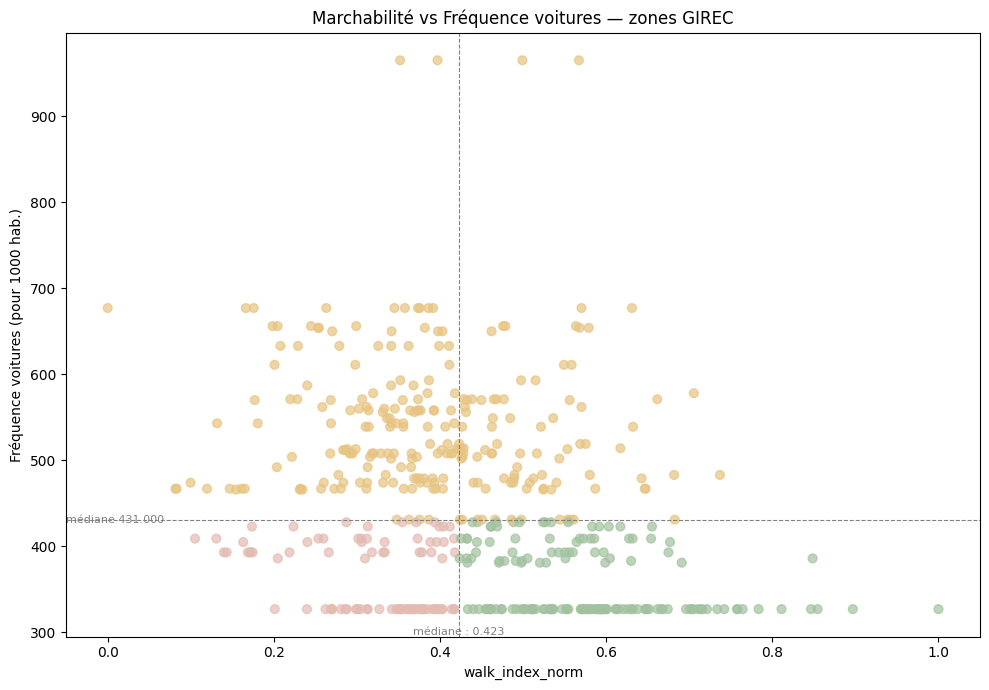

In [115]:
# ─── Calcul des médianes ────────────────────────────────────
mx = df_voit['walk_index_norm'].median()
my = df_voit['freq_voitures_24'].median()

# ─── Palette couleurs quadrants ───────────────────────────────────────────────
quadrant_colors = {
    'faible_marcha_peu_voitures'   : '#e3bbb1ff',  # ← PRIORITAIRE
    'bonne_marcha_peu_voitures'    : '#a2c29fff',
    'faible_marcha_bcp_voitures'   : '#e7c481ff',
    'bonne_marcha_bcp_voitures'    : '#e7c481ff',
}

# ─── Fonction quadrant adaptée ────────────────────────────────────────────────
def quadrant_color(row):
    if row['walk_index_norm'] < mx and row['freq_voitures_24'] < my:
        return quadrant_colors['faible_marcha_peu_voitures']
    elif row['walk_index_norm'] >= mx and row['freq_voitures_24'] < my:
        return quadrant_colors['bonne_marcha_peu_voitures']
    elif row['walk_index_norm'] < mx and row['freq_voitures_24'] >= my:
        return quadrant_colors['faible_marcha_bcp_voitures']
    else:
        return quadrant_colors['bonne_marcha_bcp_voitures']

df_voit['quad_color'] = df_voit.apply(quadrant_color, axis=1)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_voit['walk_index_norm'], df_voit['freq_voitures_24'],
           c=df_voit['quad_color'], alpha=0.7, s=40)

ax.axvline(mx, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(my, color='gray', linestyle='--', linewidth=0.8)

ax.text(mx, ax.get_ylim()[0], f'médiane : {mx:.3f}',
        color='gray', fontsize=8, ha='center', va='bottom')
ax.text(ax.get_xlim()[0], my, f'médiane {my:.3f}',
        color='gray', fontsize=8, ha='left', va='center')

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.set_xlabel('walk_index_norm')
ax.set_ylabel('Fréquence voitures (pour 1000 hab.)')
ax.set_title('Marchabilité vs Fréquence voitures — zones GIREC')
plt.tight_layout()
plt.show()

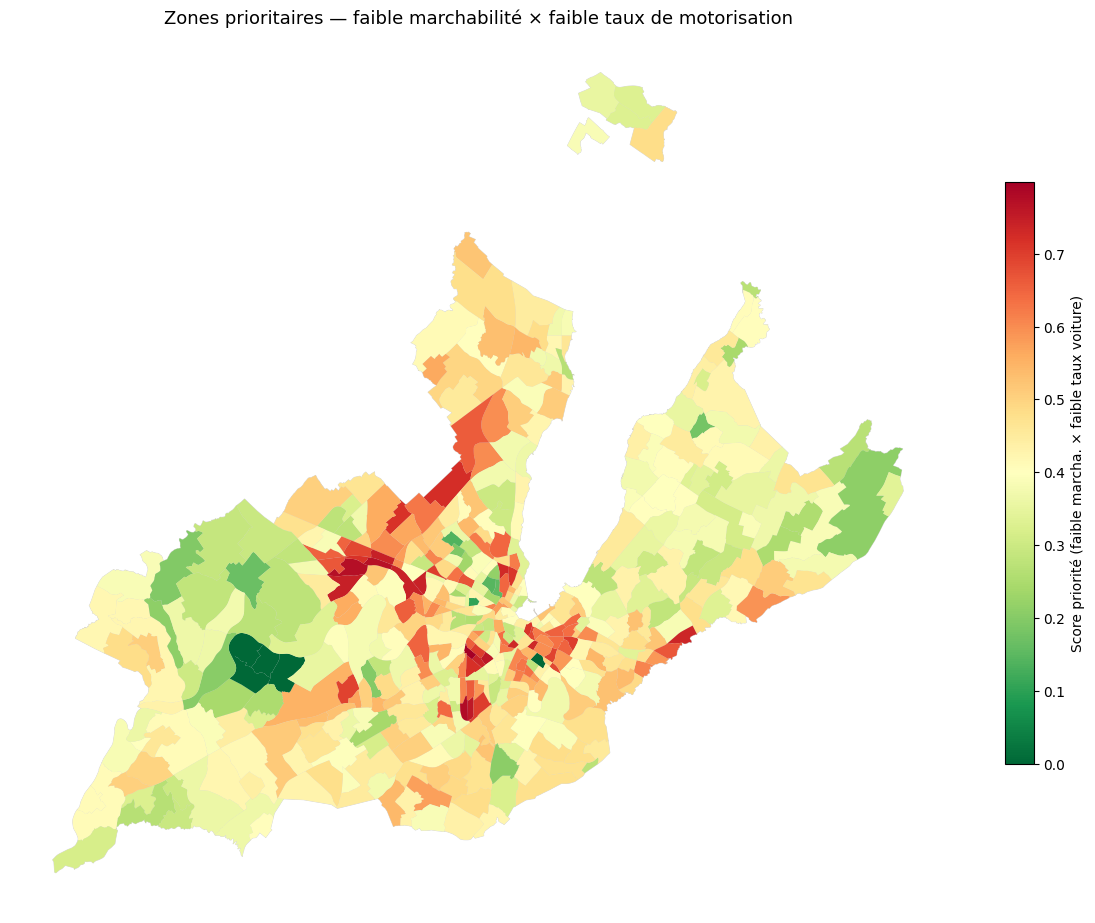

In [116]:
# Carte choroplèthe — score priorité voiture
gdf_voit = gpd.GeoDataFrame(df_voit, geometry='geometry', crs=zones_girec.crs)

fig, ax = plt.subplots(figsize=(12, 10))

zones_girec.to_crs(gdf_voit.crs).plot(
    ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5
)
gdf_voit.plot(
    column='priority_voiture',
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Score priorité (faible marcha. × faible taux voiture)', 'shrink': 0.6},
    ax=ax
)
ax.set_title('Zones prioritaires — faible marchabilité × faible taux de motorisation', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [117]:
zones_girec['voiture_norm'] = df_voit['voiture_norm']
zones_girec['priority_voiture'] = df_voit['priority_voiture']

cols = zones_girec.columns.tolist()
for col, after in [
    ('voiture_norm',      'freq_voitures_24'),
    ('priority_voiture', 'voiture_norm')
]:
    cols.insert(cols.index(after) + 1, cols.pop(cols.index(col)))
zones_girec = zones_girec[cols]

In [118]:
zones_girec.columns

Index(['OBJECTID', 'NOM', 'COMMUNE', 'NO_COM_FED', 'NO_COMM', 'CODE_SECT',
       'SECT_VILLE', 'NUMERO', 'CD_SS_SECT', 'SHAPE_AREA', 'SHAPE_LEN',
       'geometry', 'lac_cours_deau', 'fontaine', 'espaces_ouverts',
       'rez_actif', 'tp', 'amenite', 'bruit', 'temperature', 'conflit_md',
       'canopee', 'banc', 'toilette', 'air', 'connectivite', 'chemin',
       'stationnement_genant', 'accident', 'zone_apaisee', 'vitesse',
       'eclairage', 'walk_index', 'walk_index_norm', 'walk_index_unweighted',
       'Classe_Attractivité', 'Classe_Commodité', 'Classe_Infrastructure',
       'Classe_Sécurité', 'CODE', 'precarite_score_24', 'precarity_norm',
       'priority_score', 'cluster', 'cluster_label', 'IB1_quartiles_24',
       'IB2_quartiles_24', 'IB3_quartiles_24', 'IB4_quartiles_24',
       'IB5_quartiles_24', 'IB6_quartiles_24', 'delta_emploi_24',
       'freq_chomeurs_inscrits_24', 'chomeurs_inscrits_24',
       'emplois_totaux_24', 'eleve_origine_modeste_24',
       'freq_eleve_o

### DESSERT TP - SOUS-SECTEUR GIREC

In [119]:
# Qualite de desserte TP — % de recouvrement par classe pour chaque sous-secteur GIREC
dessert_tp = gpd.read_file(
    f'{input_file_path}/attributs/GE/dessert_TP/gueteklassen_oev_2023_2056.gpkg/OeV_Gueteklassen_ARE.gpkg',
    layer='OeV_Gueteklassen_ARE'
)[['KLASSE', 'KLASSE_FR', 'geometry']]

# Intersection between GIREC zones and dessert TP polygons
zones_proj = zones_girec[['CODE', 'geometry']].copy().to_crs("EPSG:2056")
zones_proj['area_zone'] = zones_proj.geometry.area

intersect = gpd.overlay(zones_proj, dessert_tp.to_crs("EPSG:2056"), how='intersection')
intersect['area_inter'] = intersect.geometry.area

# Sum intersection area per zone x class
dessert_by_zone = (
    intersect
    .groupby(['CODE', 'KLASSE'])['area_inter']
    .sum()
    .reset_index()
)

# Zone total areas
zone_areas = zones_proj[['CODE', 'area_zone']].drop_duplicates()

# Compute % coverage per class per zone
dessert_by_zone = dessert_by_zone.merge(zone_areas, on='CODE')
dessert_by_zone['pct'] = (dessert_by_zone['area_inter'] / dessert_by_zone['area_zone'] * 100).round(1)

# Pivot: one column per KLASSE
dessert_pivot = (
    dessert_by_zone.pivot(index='CODE', columns='KLASSE', values='pct')
    .fillna(0)
    .reset_index()
)
# Rename columns: desserte_pct_A, desserte_pct_B, etc.
dessert_pivot.columns = (
    ['CODE'] + [f'desserte_pct_{col}' for col in dessert_pivot.columns[1:]]
)

print(f"Zones GIREC: {len(dessert_pivot)} / {len(zones_girec)}")
print(f"Classes trouvees: {[c for c in dessert_pivot.columns if c != 'CODE']}")
print()

# Check: sum of all class % per zone (may be < 100 if zone partially outside desserte coverage)
pct_cols = [c for c in dessert_pivot.columns if c.startswith('desserte_pct_')]
dessert_pivot['desserte_pct_total_couvert'] = dessert_pivot[pct_cols].sum(axis=1).round(1)

print("Distribution du % de recouvrement total par zone:")
print(dessert_pivot['desserte_pct_total_couvert'].describe().round(1))
print()
print("Apercu:")
display(dessert_pivot.head())

# Merge into zones_girec
zones_girec = zones_girec.merge(dessert_pivot, on='CODE', how='left')

Zones GIREC: 470 / 475
Classes trouvees: ['desserte_pct_A', 'desserte_pct_B', 'desserte_pct_C', 'desserte_pct_D']

Distribution du % de recouvrement total par zone:
count    470.0
mean      87.0
std       25.1
min        0.0
25%       87.2
50%      100.0
75%      100.0
max      100.1
Name: desserte_pct_total_couvert, dtype: float64

Apercu:


,CODE,desserte_pct_A,desserte_pct_B,desserte_pct_C,desserte_pct_D,desserte_pct_total_couvert
0,ch013_6601_0000_010,0.0,0.0,0.0,13.4,13.4
1,ch013_6601_0000_029,0.0,0.0,0.0,8.4,8.4
2,ch013_6601_0000_039,0.0,0.0,0.0,79.8,79.8
3,ch013_6601_0000_040,0.0,0.0,0.0,17.5,17.5
4,ch013_6602_0000_011,0.0,0.0,95.2,4.8,100.0


In [120]:
# ─── Pondération ARE / SN 640 281 ─────────────────────────────────────────────
# Source : méthodologie ARE (Office fédéral du développement territorial)
# Poids linéaires : A=1.0, B=0.75, C=0.5, D=0.25
weights = {
    'A': 1.00,
    'B': 0.75,
    'C': 0.50,
    'D': 0.25,
}

# ─── Calcul du score de desserte ──────────────────────────────────────────────
# Les % sont entre 0 et 100 → on divise par 100 pour normaliser entre 0 et 1
zones_girec["desserte_score"] = (
    zones_girec["desserte_pct_A"] * weights['A'] +
    zones_girec["desserte_pct_B"] * weights['B'] +
    zones_girec["desserte_pct_C"] * weights['C'] +
    zones_girec["desserte_pct_D"] * weights['D']
) / 100

print("── Transport score distribution ──────────────────────")
print(zones_girec["desserte_score"].describe().round(3))
print(f"\nMin : {zones_girec['desserte_score'].min():.3f}")
print(f"Max : {zones_girec['desserte_score'].max():.3f}")

── Transport score distribution ──────────────────────
count    470.000
mean       0.639
std        0.337
min        0.000
25%        0.323
50%        0.716
75%        0.964
max        1.000
Name: desserte_score, dtype: float64

Min : 0.000
Max : 1.000


In [121]:
zones_girec

,OBJECTID,NOM,COMMUNE,NO_COM_FED,NO_COMM,CODE_SECT,SECT_VILLE,NUMERO,CD_SS_SECT,SHAPE_AREA,...,maison_indiv_25,freq_voitures_24,voiture_norm,priority_voiture,desserte_pct_A,desserte_pct_B,desserte_pct_C,desserte_pct_D,desserte_pct_total_couvert,desserte_score
0,31,Roulave,Dardagny,6620,20,00,NaN,2000020,020,1.579804e+06,...,NaN,508,0.283699,0.420100,0.0,0.0,0.0,8.3,8.3,0.02075
1,32,Essertines,Dardagny,6620,20,00,NaN,2000040,040,7.162025e+05,...,7.0,508,0.283699,0.419130,0.0,0.0,0.0,53.6,53.6,0.13400
2,33,La Tuilière,Dardagny,6620,20,00,NaN,2000010,010,1.333054e+06,...,3.0,508,0.283699,0.480849,0.0,0.0,0.0,13.8,13.8,0.03450
3,1,Signal,Bernex,6607,7,00,NaN,0700080,080,8.244912e+05,...,NaN,474,0.230408,0.466817,0.0,19.3,54.7,26.0,100.0,0.48325
4,2,Veyrier - Marais,Veyrier,6645,48,00,NaN,4500060,060,6.213745e+05,...,5.0,479,0.238245,0.471663,0.0,9.2,46.3,37.8,93.3,0.39500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,439,Saint-Paul,Cologny,6617,17,00,NaN,1700011,011,1.358225e+05,...,7.0,570,0.380878,0.340610,100.0,0.0,0.0,0.0,100.0,1.00000
471,440,Châtillon,Bernex,6607,7,00,NaN,0700020,020,1.296117e+06,...,NaN,474,0.230408,0.353884,0.0,0.0,0.0,2.9,2.9,0.00725
472,441,Narly - Lécherette,Confignon,6618,18,00,NaN,1800041,041,6.575811e+05,...,12.0,483,0.244514,0.240434,0.9,37.2,50.0,12.0,100.1,0.56800
473,442,Les Délices,Genève-Eaux-Vives,6621,21,03,DELICES GROTTES,2103010,010,1.508622e+05,...,4.0,327,0.000000,0.388259,100.0,0.0,0.0,0.0,100.0,1.00000


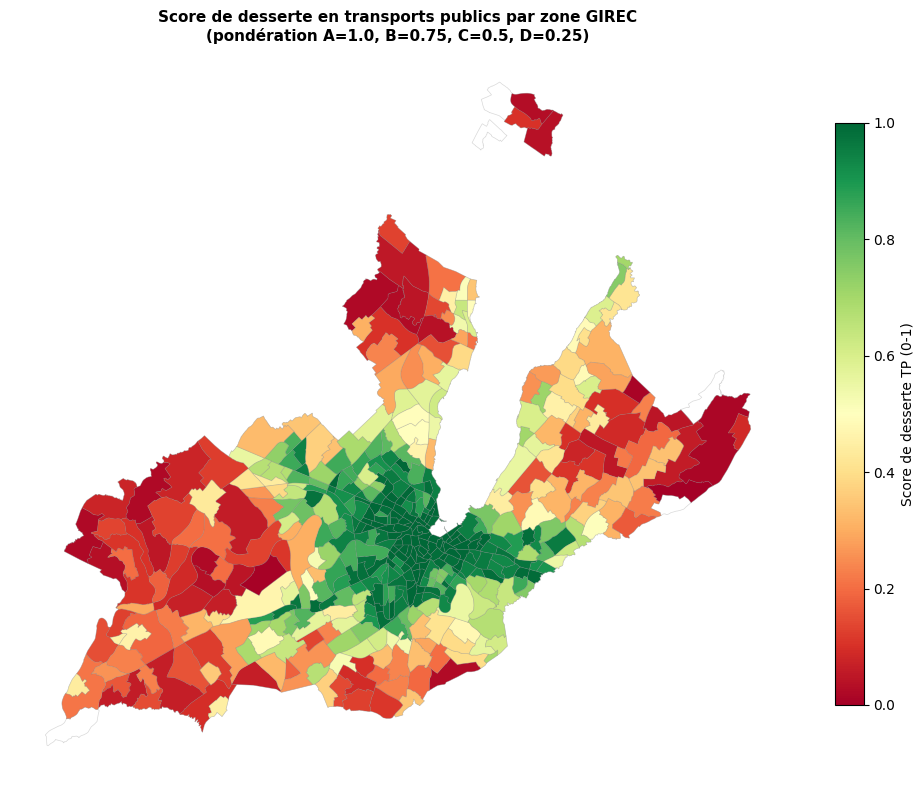

In [122]:
fig, ax = plt.subplots(figsize=(10, 10))

# ─── Background zones sans données ───────────────────────────────────────────
zones_girec.plot(ax=ax, color="white", edgecolor=(0.5, 0.5, 0.5, 0.3), linewidth=0.5)

# ─── Plot transport score ──────────────────────────────────────────────────────
zones_girec.dropna(subset=["desserte_score"]).plot(
    column="desserte_score",
    cmap="RdYlGn",
    linewidth=0.5,
    edgecolor=(0.5, 0.5, 0.5, 0.3),
    legend=True,
    ax=ax,
    vmin=0, vmax=1,
    legend_kwds={"label": "Score de desserte TP (0-1)", "shrink": 0.6}
)

ax.set_title(
    "Score de desserte en transports publics par zone GIREC\n"
    "(pondération A=1.0, B=0.75, C=0.5, D=0.25)",
    fontweight="bold", fontsize=11
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

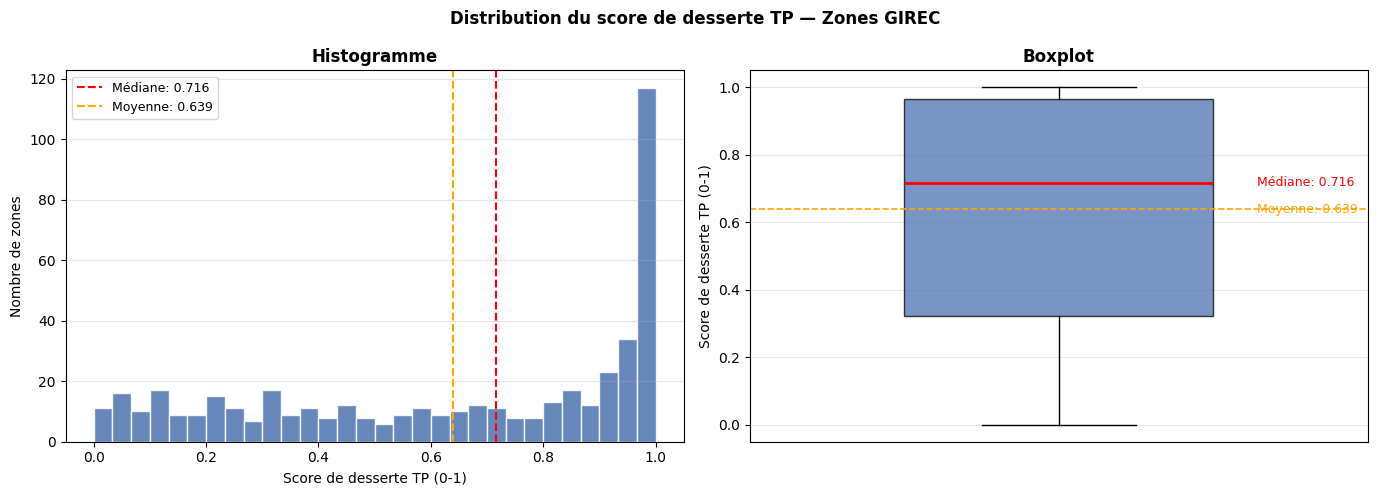

── Stats desserte_score ──────────────────────────────
count    470.000
mean       0.639
std        0.337
min        0.000
25%        0.323
50%        0.716
75%        0.964
max        1.000
Name: desserte_score, dtype: float64


In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution du score de desserte TP — Zones GIREC", fontweight="bold")

data = zones_girec["desserte_score"].dropna()

# ─── Histogramme ──────────────────────────────────────────────────────────────
axes[0].hist(data, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(data.median(), color="red",    linestyle="--", label=f"Médiane: {data.median():.3f}")
axes[0].axvline(data.mean(),   color="orange", linestyle="--", label=f"Moyenne: {data.mean():.3f}")
axes[0].set_title("Histogramme", fontweight="bold")
axes[0].set_xlabel("Score de desserte TP (0-1)")
axes[0].set_ylabel("Nombre de zones")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# ─── Boxplot ──────────────────────────────────────────────────────────────────
bp = axes[1].boxplot(data.values, vert=True, patch_artist=True, widths=0.5,
                     medianprops=dict(color="red", linewidth=2),
                     flierprops=dict(marker="o", markersize=3, alpha=0.4))
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][0].set_alpha(0.75)
axes[1].axhline(data.mean(), color="orange", linestyle="--", linewidth=1.2)
axes[1].text(1.32, data.median(), f"Médiane: {data.median():.3f}", va="center", color="red",    fontsize=9)
axes[1].text(1.32, data.mean(),   f"Moyenne: {data.mean():.3f}",   va="center", color="orange", fontsize=9)
axes[1].set_title("Boxplot", fontweight="bold")
axes[1].set_ylabel("Score de desserte TP (0-1)")
axes[1].set_xticks([])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("── Stats desserte_score ──────────────────────────────")
print(data.describe().round(3))

Surface totale canton : 240.7 km²
Zones avec données    : 470


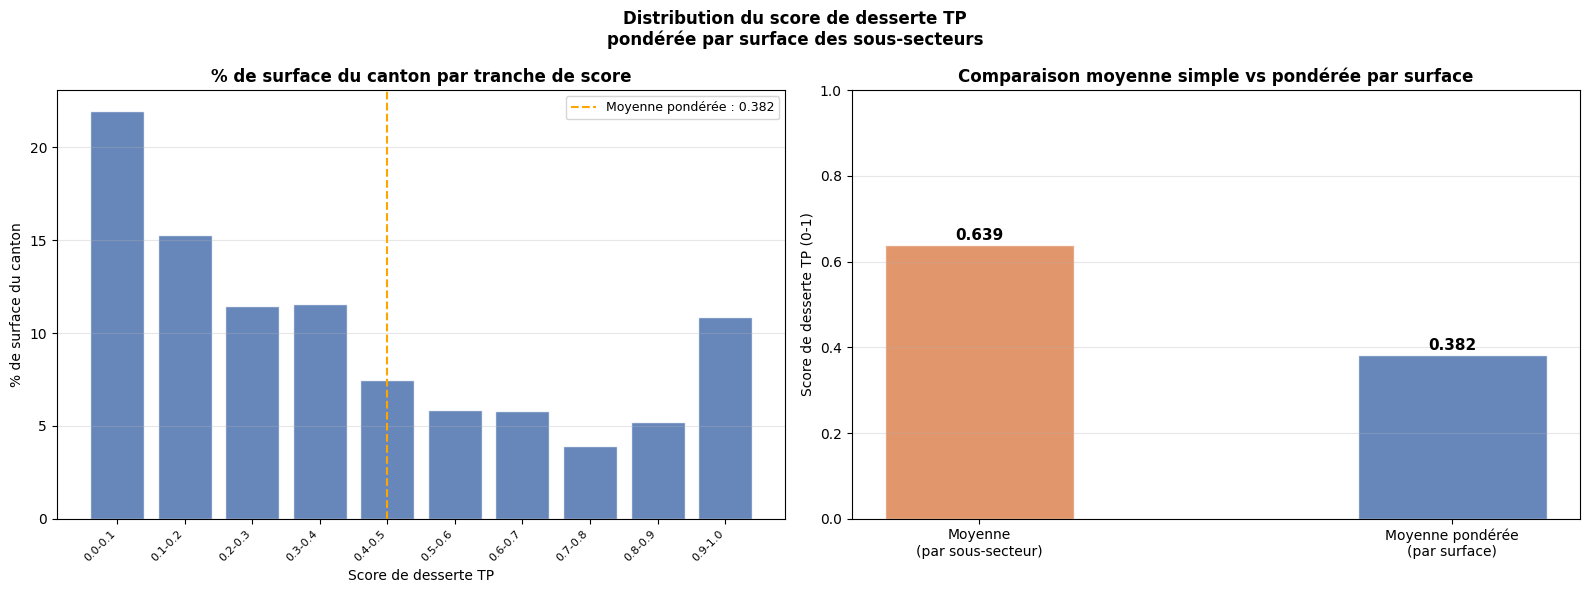


Moyenne simple (par sous-secteur) : 0.639
Moyenne pondérée (par surface)    : 0.382

% de surface par tranche :
score_bin  pct_area
  0.0-0.1 21.985613
  0.1-0.2 15.267107
  0.2-0.3 11.477549
  0.3-0.4 11.568978
  0.4-0.5  7.486424
  0.5-0.6  5.884230
  0.6-0.7  5.821301
  0.7-0.8  3.941436
  0.8-0.9  5.184911
  0.9-1.0 10.881967


In [124]:
# ─── Calcul de la surface de chaque sous-secteur ──────────────────────────────
zones_girec["area"] = zones_girec.geometry.area  # en m²

data_weighted = zones_girec[["desserte_score", "area"]].dropna()

total_area = data_weighted["area"].sum()
data_weighted["pct_area"] = data_weighted["area"] / total_area * 100

print(f"Surface totale canton : {total_area/1e6:.1f} km²")
print(f"Zones avec données    : {len(data_weighted)}")

# ─── Distribution pondérée par surface ────────────────────────────────────────
# % de surface du canton par tranche de score
bins = np.arange(0, 1.05, 0.1)
labels_bins = [f"{b:.1f}-{b+0.1:.1f}" for b in bins[:-1]]

data_weighted["score_bin"] = pd.cut(data_weighted["desserte_score"], bins=bins, labels=labels_bins)

area_by_bin = (data_weighted
               .groupby("score_bin", observed=True)["area"]
               .sum()
               .reset_index())
area_by_bin["pct_area"] = area_by_bin["area"] / total_area * 100

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribution du score de desserte TP\npondérée par surface des sous-secteurs",
             fontweight="bold")

# ── Histogramme pondéré par surface ───────────────────────────────────────────
axes[0].bar(range(len(area_by_bin)), area_by_bin["pct_area"],
            color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_xticks(range(len(area_by_bin)))
axes[0].set_xticklabels(area_by_bin["score_bin"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("% de surface du canton par tranche de score", fontweight="bold")
axes[0].set_xlabel("Score de desserte TP")
axes[0].set_ylabel("% de surface du canton")
axes[0].grid(axis="y", alpha=0.3)

# Médiane pondérée
median_w = np.average(data_weighted["desserte_score"],
                      weights=data_weighted["area"])
axes[0].axvline(
    next(i for i, b in enumerate(labels_bins) if float(b.split('-')[0]) >= median_w),
    color="orange", linestyle="--", linewidth=1.5,
    label=f"Moyenne pondérée : {median_w:.3f}"
)
axes[0].legend(fontsize=9)

# ── Comparaison non pondéré vs pondéré ────────────────────────────────────────
mean_unweighted = data_weighted["desserte_score"].mean()
mean_weighted   = np.average(data_weighted["desserte_score"], weights=data_weighted["area"])

categories = ["Moyenne\n(par sous-secteur)", "Moyenne pondérée\n(par surface)"]
values     = [mean_unweighted, mean_weighted]
colors     = ["#DD8452", "#4C72B0"]

bars = axes[1].bar(categories, values, color=colors, edgecolor="white", alpha=0.85, width=0.4)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

axes[1].set_title("Comparaison moyenne simple vs pondérée par surface",
                  fontweight="bold")
axes[1].set_ylabel("Score de desserte TP (0-1)")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Print résumé ─────────────────────────────────────────────────────────────
print(f"\nMoyenne simple (par sous-secteur) : {mean_unweighted:.3f}")
print(f"Moyenne pondérée (par surface)    : {mean_weighted:.3f}")
print(f"\n% de surface par tranche :")
print(area_by_bin[["score_bin", "pct_area"]].to_string(index=False))


── priority_dessert ──────────────────────────────────
count    470.000
mean       0.147
std        0.140
min        0.000
25%        0.014
50%        0.110
75%        0.267
max        0.521
Name: priority_dessert, dtype: float64

Top 5 zones prioritaires :
                 NOM   COMMUNE  walk_index_norm  voiture_norm  desserte_score  priority_dessert
         Compesières Bardonnex         0.131624      0.338558         0.09225          0.521394
           Richelien   Versoix         0.362861      0.163009         0.04325          0.510215
                Cara  Presinge         0.203629      0.258621         0.16975          0.490190
Aéroport - FORESTIER    Meyrin         0.081496      0.219436         0.33875          0.474084
    Petit-Saint-Loup   Versoix         0.347941      0.163009         0.14050          0.469087


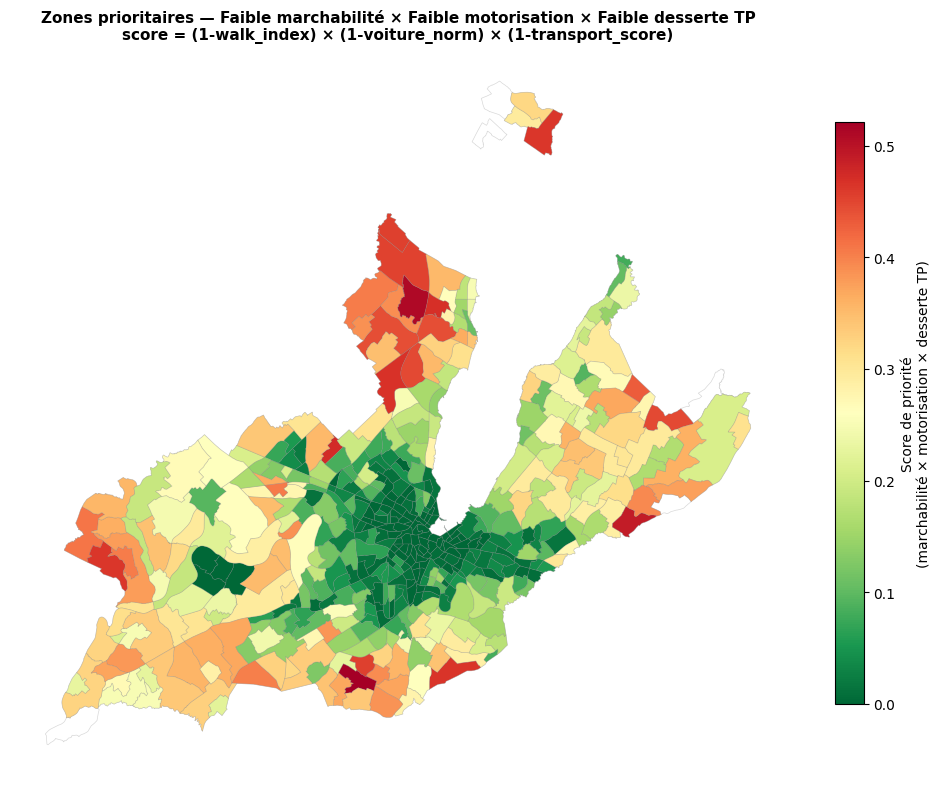

In [125]:
zones_girec["priority_dessert"] = (
    (1 - zones_girec["walk_index_norm"]) *
    (1 - zones_girec["voiture_norm"]) *
    (1 - zones_girec["desserte_score"])
)

print("\n── priority_dessert ──────────────────────────────────")
print(zones_girec["priority_dessert"].describe().round(3))
print(f"\nTop 5 zones prioritaires :")
print(zones_girec.nlargest(5, "priority_dessert")[["NOM", "COMMUNE", "walk_index_norm", "voiture_norm", "desserte_score", "priority_dessert"]].to_string(index=False))

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

zones_girec.plot(ax=ax, color="white", edgecolor=(0.5, 0.5, 0.5, 0.3), linewidth=0.5)

zones_girec.dropna(subset=["priority_dessert"]).plot(
    column="priority_dessert",
    cmap="RdYlGn_r",  # ← rouge = prioritaire, vert = pas urgent
    linewidth=0.5,
    edgecolor=(0.5, 0.5, 0.5, 0.3),
    legend=True,
    ax=ax,
    legend_kwds={
        "label" : "Score de priorité\n(marchabilité × motorisation × desserte TP)",
        "shrink": 0.6
    }
)

ax.set_title(
    "Zones prioritaires — Faible marchabilité × Faible motorisation × Faible desserte TP\n"
    "score = (1-walk_index) × (1-voiture_norm) × (1-transport_score)",
    fontweight="bold", fontsize=11
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### DESSERTE TP - AGGLO_CARREAUX

In [126]:
# ─── Intersection entre agglo_carreau et dessert TP ───────────────────────────
carreau_proj = agglo_carreau[['GRID_ID', 'geometry']].copy().to_crs("EPSG:2056")
carreau_proj['area_zone'] = carreau_proj.geometry.area

intersect_carreau = gpd.overlay(carreau_proj, dessert_tp.to_crs("EPSG:2056"), how='intersection')
intersect_carreau['area_inter'] = intersect_carreau.geometry.area

# ─── Sum intersection area per carreau x class ────────────────────────────────
dessert_by_carreau = (
    intersect_carreau
    .groupby(['GRID_ID', 'KLASSE'])['area_inter']
    .sum()
    .reset_index()
)

# ─── Zone total areas ──────────────────────────────────────────────────────────
carreau_areas = carreau_proj[['GRID_ID', 'area_zone']].drop_duplicates()

# ─── Compute % coverage per class per carreau ─────────────────────────────────
dessert_by_carreau = dessert_by_carreau.merge(carreau_areas, on='GRID_ID')
dessert_by_carreau['pct'] = (
    dessert_by_carreau['area_inter'] / dessert_by_carreau['area_zone'] * 100
).round(1)

# ─── Pivot ────────────────────────────────────────────────────────────────────
dessert_pivot_carreau = (
    dessert_by_carreau.pivot(index='GRID_ID', columns='KLASSE', values='pct')
    .fillna(0)
    .reset_index()
)

dessert_pivot_carreau.columns = (
    ['GRID_ID'] + [f'desserte_pct_{col}' for col in dessert_pivot_carreau.columns[1:]]
)

# ─── Check ────────────────────────────────────────────────────────────────────
pct_cols = [c for c in dessert_pivot_carreau.columns if c.startswith('desserte_pct_')]
dessert_pivot_carreau['desserte_pct_total_couvert'] = dessert_pivot_carreau[pct_cols].sum(axis=1).round(1)

print(f"Carreaux avec desserte : {len(dessert_pivot_carreau)} / {len(agglo_carreau)}")
print(f"Classes trouvées       : {pct_cols}")
print()
print("Distribution du % de recouvrement total par carreau:")
print(dessert_pivot_carreau['desserte_pct_total_couvert'].describe().round(1))

# ─── Merge into agglo_carreau ─────────────────────────────────────────────────
agglo_carreau = agglo_carreau.merge(dessert_pivot_carreau, on='GRID_ID', how='left')

# ─── Transport score pour chaque carreau ──────────────────────────────────────
weights = {'A': 1.00, 'B': 0.75, 'C': 0.50, 'D': 0.25}

agglo_carreau["desserte_score"] = (
    agglo_carreau.get("desserte_pct_A", 0) * weights['A'] +
    agglo_carreau.get("desserte_pct_B", 0) * weights['B'] +
    agglo_carreau.get("desserte_pct_C", 0) * weights['C'] +
    agglo_carreau.get("desserte_pct_D", 0) * weights['D']
) / 100

Carreaux avec desserte : 4598 / 5984
Classes trouvées       : ['desserte_pct_A', 'desserte_pct_B', 'desserte_pct_C', 'desserte_pct_D']

Distribution du % de recouvrement total par carreau:
count    4598.0
mean       87.4
std        27.5
min         0.0
25%        99.2
50%       100.0
75%       100.0
max       100.1
Name: desserte_pct_total_couvert, dtype: float64


In [127]:
agglo_carreau

,OBJECTID,GRID_ID,PARTEMP,H_P_REGG,D_POP_HA,D_EMP_HA,POP_TOT_GG,EMP_TOT_GG,POP_TOT_00,EMP_TOT_00,...,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité,walk_index_norm,desserte_pct_A,desserte_pct_B,desserte_pct_C,desserte_pct_D,desserte_pct_total_couvert,desserte_score
0,59798,FF-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.726000,0.670700,0.500000,0.634510,0.0,0.0,0.0,0.0,0.0,0.00000
1,59799,FG-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.584140,0.672544,0.500000,0.541808,0.0,0.0,0.0,66.7,66.7,0.16675
2,59801,FI-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.503261,0.339363,0.321736,0.329223,0.0,0.0,82.1,17.9,100.0,0.45525
3,59802,FJ-245,0.09434,NaN,24.00,2.5,58,9,96,10,...,0.498820,0.338588,0.598299,0.550307,0.0,0.0,100.0,0.0,100.0,0.50000
4,59803,FK-245,0.00000,NaN,0.75,0.0,3,0,3,0,...,0.386292,0.495801,0.402370,0.300072,0.0,0.0,77.7,22.3,100.0,0.44425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5979,118172,HM-124,NaN,NaN,0.00,0.0,0,0,0,0,...,0.397800,0.336659,0.417884,0.257419,NaN,NaN,NaN,NaN,NaN,NaN
5980,118251,HL-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.763142,0.671664,0.500000,0.659367,NaN,NaN,NaN,NaN,NaN,NaN
5981,118252,HM-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.561049,0.670841,0.500000,0.525945,NaN,NaN,NaN,NaN,NaN,NaN
5982,118253,HN-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.368046,0.670700,0.472200,0.385352,NaN,NaN,NaN,NaN,NaN,NaN


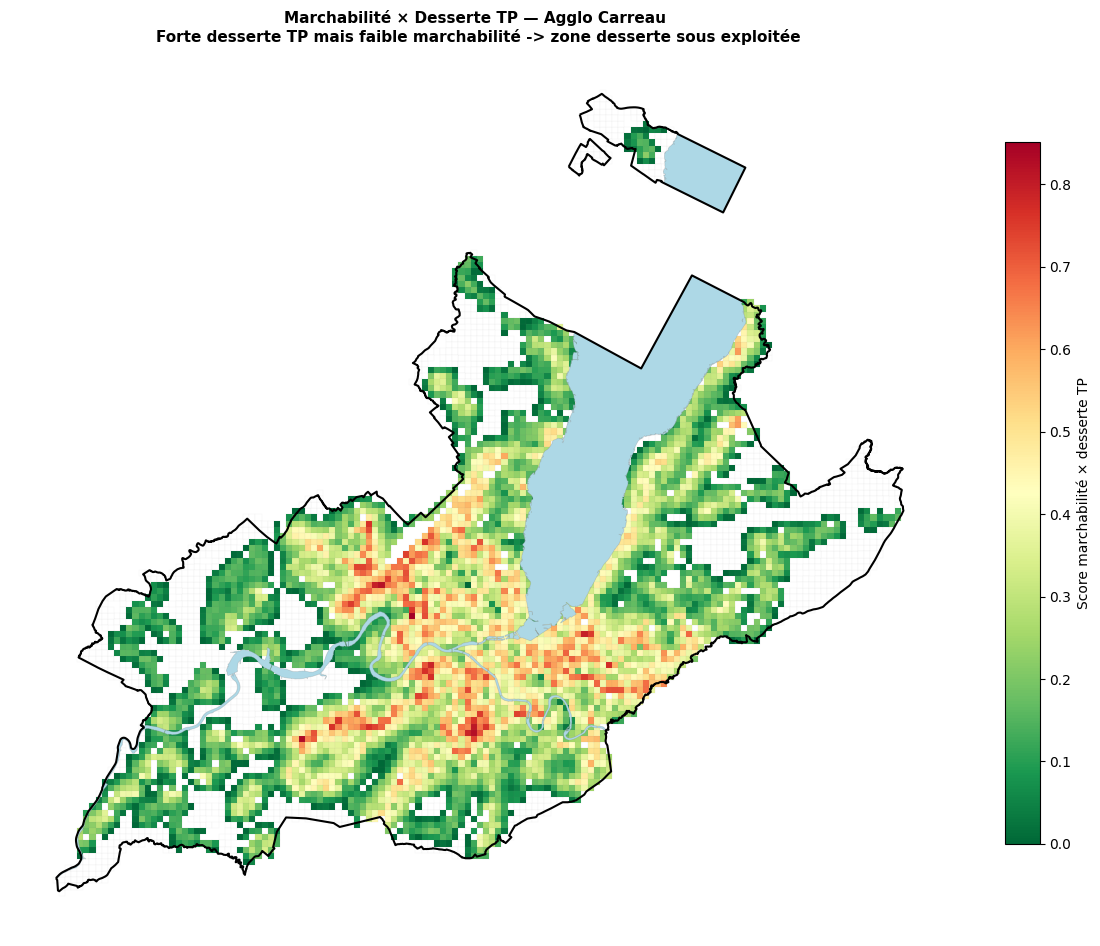

In [128]:
# ─── Score marchabilité × desserte ───────────────────────────────────────────
agglo_carreau["score_marcha_desserte"] = (
    (1 - agglo_carreau["walk_index_norm"]) * agglo_carreau["desserte_score"]
)

fig, ax = plt.subplots(figsize=(12, 12))

agglo_carreau.plot(ax=ax, color="white", edgecolor=(0.5, 0.5, 0.5, 0.1), linewidth=0.3)

agglo_carreau.dropna(subset=["score_marcha_desserte"]).plot(
    column="score_marcha_desserte",
    cmap="RdYlGn_r",
    linewidth=0.3,
    edgecolor=(0.5, 0.5, 0.5, 0.1),
    legend=True,
    ax=ax,
    legend_kwds={
        "label" : "Score marchabilité × desserte TP",
        "shrink": 0.6
    }
)

canton_GE.boundary.plot(ax=ax, color="black", linewidth=1.5)
lac_clipped = gpd.clip(lac.to_crs(canton_GE.crs), canton_GE)
lac_clipped.plot(ax=ax, color="lightblue", edgecolor=(0.5, 0.5, 0.5, 0.3), linewidth=0.5)



ax.set_title(
    "Marchabilité × Desserte TP — Agglo Carreau \n" \
    "Forte desserte TP mais faible marchabilité -> zone desserte sous exploitée",
    fontweight="bold", fontsize=11
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [129]:
agglo_carreau

,OBJECTID,GRID_ID,PARTEMP,H_P_REGG,D_POP_HA,D_EMP_HA,POP_TOT_GG,EMP_TOT_GG,POP_TOT_00,EMP_TOT_00,...,Classe_Infrastructure,Classe_Sécurité,walk_index_norm,desserte_pct_A,desserte_pct_B,desserte_pct_C,desserte_pct_D,desserte_pct_total_couvert,desserte_score,score_marcha_desserte
0,59798,FF-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.670700,0.500000,0.634510,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000
1,59799,FG-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.672544,0.500000,0.541808,0.0,0.0,0.0,66.7,66.7,0.16675,0.076403
2,59801,FI-245,NaN,NaN,0.00,0.0,0,0,0,0,...,0.339363,0.321736,0.329223,0.0,0.0,82.1,17.9,100.0,0.45525,0.305371
3,59802,FJ-245,0.09434,NaN,24.00,2.5,58,9,96,10,...,0.338588,0.598299,0.550307,0.0,0.0,100.0,0.0,100.0,0.50000,0.224846
4,59803,FK-245,0.00000,NaN,0.75,0.0,3,0,3,0,...,0.495801,0.402370,0.300072,0.0,0.0,77.7,22.3,100.0,0.44425,0.310943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5979,118172,HM-124,NaN,NaN,0.00,0.0,0,0,0,0,...,0.336659,0.417884,0.257419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5980,118251,HL-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.671664,0.500000,0.659367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5981,118252,HM-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.670841,0.500000,0.525945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5982,118253,HN-126,NaN,NaN,0.00,0.0,0,0,0,0,...,0.670700,0.472200,0.385352,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### SECURITE/INSECURITE

# EXPORTS

In [130]:
zones_girec.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_girec.gpkg"), driver="GPKG")
zones_girec.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_girec.parquet')
zones_girec.to_csv(f'{output_step3_path}/step3_aggregated_index_girec.csv')
print("zones_girec exported as .gpkg, .parquet, .csv")

agglo_carreau.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_carreau200.gpkg"), driver="GPKG")
agglo_carreau.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_carreau200.parquet')
print("agglo_carreau exported as .gpkg, .parquet")

zones_communes.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_communes.gpkg"), driver="GPKG")
zones_communes.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_communes.parquet')
print("zones_communes exported as .gpkg, .parquet")

zones_communes_GE_fusionnee.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_aggregated_index_communes_GE_fusionnee.gpkg"), driver="GPKG")
zones_communes_GE_fusionnee.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_aggregated_index_communes_GE_fusionnee.parquet')
print("zones_commune_GE_fusionne exported as .gpkg, .parquet")

zones_girec exported as .gpkg, .parquet, .csv
agglo_carreau exported as .gpkg, .parquet
zones_communes exported as .gpkg, .parquet
zones_commune_GE_fusionne exported as .gpkg, .parquet
